### Section 1: Data Ingestion, Cleaning & Feature Preparation

1) Loads taxi trip data from a shared Databricks table into Spark
2) Removes duplicate rows to avoid repeated observations
3) Drops rows with missing values in key variables (fare, distance, pickup/drop-off locations)
4) Filters out unrealistic or invalid trips (e.g. zero distance, zero fare, extreme total amounts)
5) Ensures the dataset only includes meaningful and reliable taxi journeys
6) Converts categorical variables (e.g. vendor, rate type, payment method) into numerical form
7) Uses indexing and one-hot encoding to prepare data for machine learning models
8) Organises transformations using a pipeline for efficiency and consistency
9) Produces a clean, structured dataset ready for analysis and modelling

In [0]:
## 1. Data Ingestion & Cleaning

df = spark.table("largedata.default.nyc_tlc_yellow_2024_01") #Update the file path variable if it differs

# Verify the data is loaded
display(df.limit(5))
len(df.columns) # number of columns 19

# 1.1 Data Cleaning
from pyspark.sql.functions import col,when,count,isnan,unix_timestamp,max,abs

# Remove duplicates
df_no_duplicates = df.dropDuplicates()

# Handle missing values
df_cleaned_nulls = df_no_duplicates.dropna(subset=["fare_amount", "trip_distance", "PULocationID", "DOLocationID"])
	
# 2. Count and display missing values in all columns
df_cleaned_nulls.select([count(when(col(c).isNull(), c)).alias(c) for c in df_cleaned_nulls.columns]).toPandas()

# 3. We find NULLS in passenger_count for 140162 records.Replace null passenger_count with 1
# These could occur due to data entry error, missed during trip entry transmission or invalid records.
# We will impute these values with the mean value rounded to the lowest integer. In this case a trip should have atleast 1 passenger.
df_impute = df_cleaned_nulls.na.fill({"passenger_count": 1})

# Check and display how many records have trip_distance>150. May have to filter both trip_distance and location IDs
df_impute.filter((col("trip_distance") > 150)).toPandas()  ##35 records displayed. 

# Handle Outliers (Filtering based on logical taxi trip constraints)
# Filtering for trips with distance > 0 as valid trip and fare > 0 to ensure data quality
df_filtered = df_impute.filter(
    (col("trip_distance") > 0 ) & 
    (col("fare_amount") > 0) & 
    (col("passenger_count") > 0) &
    (col("total_amount") < 1000))
df_filtered.toPandas()
df_filtered.count() #2839052

# 4. Business rules: Sum of all total_check computed should be equal to total_amount in dataset
df_valid_newcols = df_filtered.withColumn("total_check", 
                       col("fare_amount") + col("tip_amount") + col("tolls_amount") + 
                       col("mta_tax") + col("extra") + col("improvement_surcharge") + col("congestion_surcharge")+col("Airport_fee"))
fare_mismatch = df_valid_newcols.filter(abs(col("total_amount") - col("total_check")) > 1)
fare_mismatch.count() ###observed mismatches-> 601461
#df_valid_newcols.count()
#len(df_valid_newcols.columns)

# 5. Valid legal passenger_count
# Drop these records as NYC yellow taxi can have max upto 5 passengers only
invalid_passengers = df_filtered.filter(col("passenger_count") > 5)
print("Trips with >5 passengers:", invalid_passengers.count()) ###22221
df_valid_passcount = df_valid_newcols.filter(col("passenger_count") <= 5)
df_valid_passcount.count()#2816831

#6. store_and_fwd_flag column convert Y/N to 1/0
df_flag_bin = df_valid_passcount.withColumn(
    "store_and_fwd_flag_bin",
    when(col("store_and_fwd_flag") == "Y", 1).otherwise(0)
)
df_flag_bin.count()

#7.VendorID = 3 or 5 is NOT valid. Only 1,2,4,6,7 are valid vendorIDs
df_flag_bin.select("vendorid").distinct().show() #1,2,6 are in our dataset.All valid no transformation required.

df_final_cleaned = df_flag_bin

print(f"Original Row Count: {df.count()}")
print(f"Cleaned Row Count: {df_final_cleaned.count()}")

# 1.2 Convert Categorical Variables
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline

# Categorical columns to be processed
categorical_cols = ["VendorID", "RatecodeID", "payment_type"]

# Indexing: Converts categories to numerical indices
indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_indexed", handleInvalid="keep") for c in categorical_cols]

# Encoding: Converts indices to binary vectors (for Regression)
encoders = [OneHotEncoder(inputCol=f"{c}_indexed", outputCol=f"{c}_vec") for c in categorical_cols]


VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
2,2024-01-29T04:10:45.000Z,2024-01-29T04:16:57.000Z,2.0,0.95,1.0,N,162,161,1,8.6,1.0,0.5,2.0,0.0,1.0,15.6,2.5,0.0
2,2024-01-29T04:24:45.000Z,2024-01-29T04:57:27.000Z,2.0,15.45,5.0,N,172,97,1,70.0,0.0,0.0,15.12,13.88,1.0,100.0,0.0,0.0
1,2024-01-29T04:58:20.000Z,2024-01-29T05:10:55.000Z,2.0,3.9,1.0,N,146,107,2,19.1,3.5,0.5,0.0,0.0,1.0,24.1,2.5,0.0
2,2024-01-29T04:05:52.000Z,2024-01-29T04:25:36.000Z,1.0,12.0,1.0,N,138,132,1,46.4,6.0,0.5,10.78,0.0,1.0,66.43,0.0,1.75
1,2024-01-29T04:07:44.000Z,2024-01-29T04:28:13.000Z,1.0,5.9,1.0,N,246,74,1,24.7,3.5,0.5,5.95,0.0,1.0,35.65,2.5,0.0


Trips with >5 passengers: 22221
+--------+
|vendorid|
+--------+
|       2|
|       1|
|       6|
+--------+

Original Row Count: 2964624
Cleaned Row Count: 2816831


In [0]:
# Apply transformations using a Pipeline
pipeline = Pipeline(stages=indexers + encoders)
pipeline_model = pipeline.fit(df_final_cleaned)
df_transformed = pipeline_model.transform(df_final_cleaned)

# Show the new numerical representations
display(df_transformed.select("VendorID", "VendorID_indexed", "VendorID_vec").limit(5))

VendorID,VendorID_indexed,VendorID_vec
1,1.0,"{""type"":""0"",""size"":""3"",""indices"":[""1""],""values"":[""1.0""]}"
2,0.0,"{""type"":""0"",""size"":""3"",""indices"":[""0""],""values"":[""1.0""]}"
1,1.0,"{""type"":""0"",""size"":""3"",""indices"":[""1""],""values"":[""1.0""]}"
2,0.0,"{""type"":""0"",""size"":""3"",""indices"":[""0""],""values"":[""1.0""]}"
2,0.0,"{""type"":""0"",""size"":""3"",""indices"":[""0""],""values"":[""1.0""]}"


### Section 2: Exploratory Data Analysis (EDA)
- 2.1 Analyzing Dataset Integrity
- 2.1.1 Verifying Column Availability
- 2.1.2 Reason Behind the Column Verification
- 2.1.3 Identifying the Problem
- 2.1.4 Implementing Corrections
- 2.1.5 Extracting Summary Statistics for Numeric Features
- 2.1.6 Visualization of Numeric Data
- 2.1.7 Correlating Insights Between Numeric Variables
- 2.1.8 Exploring Relationships Through Scatter Plots
- 2.1.9 Identifying Outliers Using Box Plots
- 2.1.10 Geospatial Analysis (Conditional on Latitude/Longitude Availability)


Summary Statistics:
avg_trip_distance: 3.30
std_trip_distance: 4.41
min_trip_distance: 0.01
max_trip_distance: 277.40
avg_fare_amount: 18.53
std_fare_amount: 17.22
min_fare_amount: 0.01
max_fare_amount: 912.30
avg_total_amount: 27.39
std_total_amount: 21.71
min_total_amount: 1.01
max_total_amount: 940.93
avg_passenger_count: 1.30
std_passenger_count: 0.72
min_passenger_count: 1.00
max_passenger_count: 5.00
Converting to pandas for visualizations...


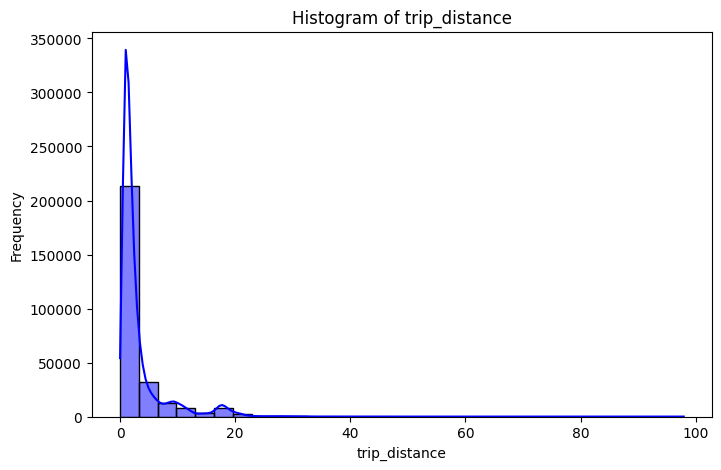

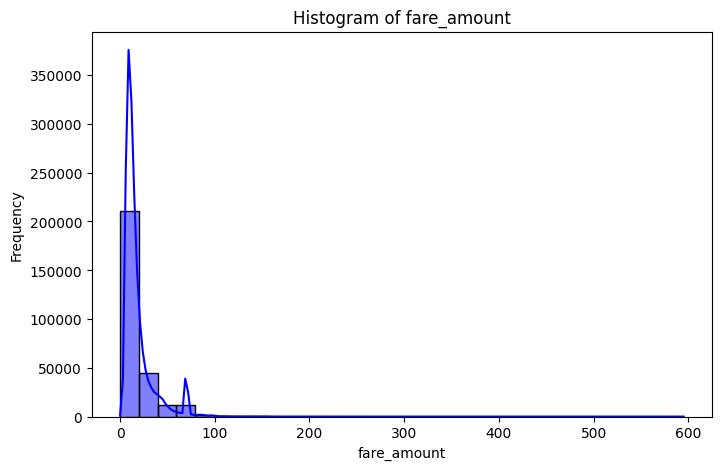

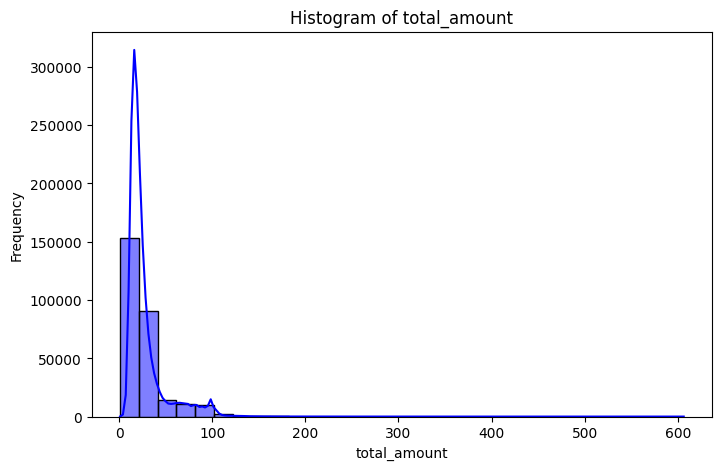

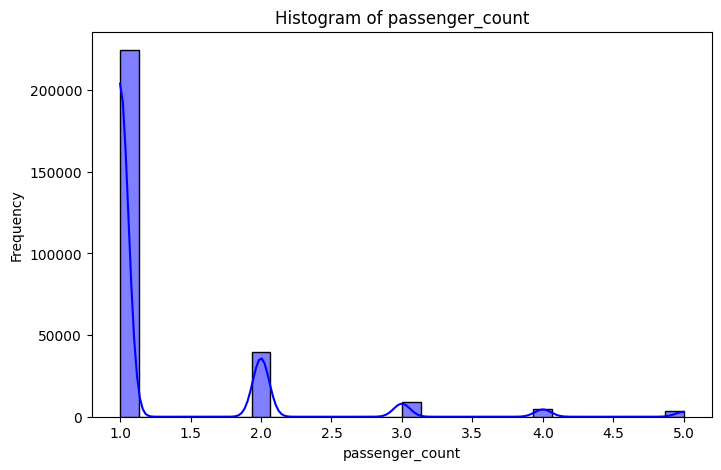

Generating box plots to detect outliers...


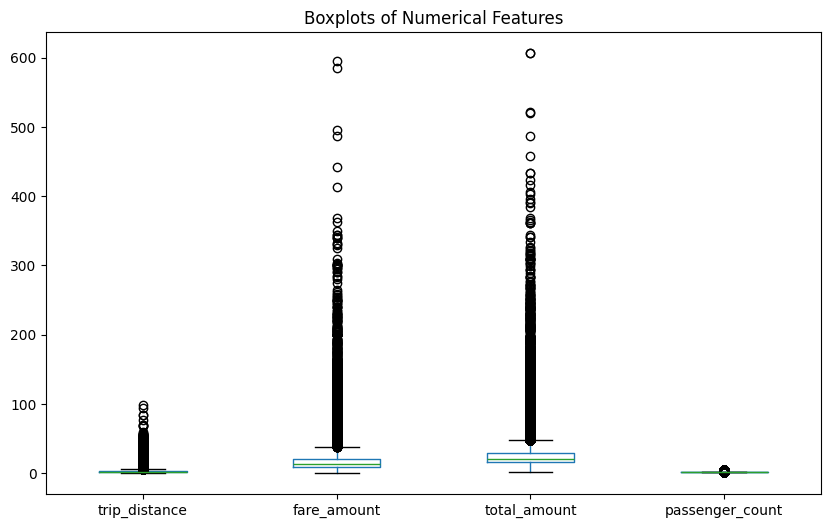

Generating scatter plot for trip_distance vs fare_amount...


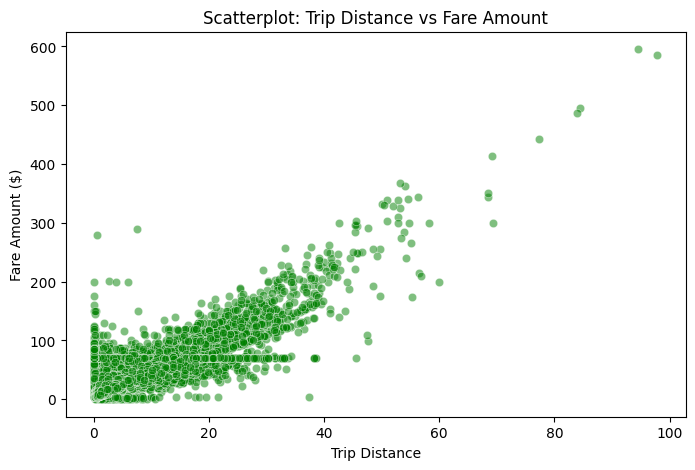

Skipping geospatial analysis. Latitude and longitude columns are missing.


In [0]:
## 2. exploratory data analysis (eda)
from pyspark.sql.functions import mean, stddev, min, max as max_
import matplotlib.pyplot as plt
import seaborn as sns
from pandas import DataFrame

# Use the transformed dataframe from the previous step
df_eda = df_transformed.filter(col("trip_distance") < 800 )  # Input dataframe for EDA

# Step 1: Summary Statistics
numerical_cols = ["trip_distance", "fare_amount", "total_amount", "passenger_count"]

summary_df = df_eda.agg(
    mean("trip_distance").alias("avg_trip_distance"),
    stddev("trip_distance").alias("std_trip_distance"),
    min("trip_distance").alias("min_trip_distance"),
    max_("trip_distance").alias("max_trip_distance"),
    
    mean("fare_amount").alias("avg_fare_amount"),
    stddev("fare_amount").alias("std_fare_amount"),
    min("fare_amount").alias("min_fare_amount"),
    max_("fare_amount").alias("max_fare_amount"),
    
    mean("total_amount").alias("avg_total_amount"),
    stddev("total_amount").alias("std_total_amount"),
    min("total_amount").alias("min_total_amount"),
    max_("total_amount").alias("max_total_amount"),
    
    mean("passenger_count").alias("avg_passenger_count"),
    stddev("passenger_count").alias("std_passenger_count"),
    min("passenger_count").alias("min_passenger_count"),
    max_("passenger_count").alias("max_passenger_count")
)

summary_stats = summary_df.collect()[0].asDict()
print("Summary Statistics:")
for k, v in summary_stats.items():
    print(f"{k}: {v:.2f}")

# Step 2: Visualizations
print("Converting to pandas for visualizations...")
df_pd = DataFrame(df_eda.select(numerical_cols).sample(fraction=0.1).collect(), columns=numerical_cols)

# Histograms
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df_pd[col], kde=True, bins=30, color='blue')
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# Box Plots
print("Generating box plots to detect outliers...")
df_pd.boxplot(grid=False, figsize=(10, 6))
plt.title("Boxplots of Numerical Features")
plt.show()

# Scatter Plots for Relationships: Trip Distance vs Fare Amount
print("Generating scatter plot for trip_distance vs fare_amount...")
plt.figure(figsize=(8, 5))
sns.scatterplot(x="trip_distance", y="fare_amount", data=df_pd, alpha=0.5, color='green')
plt.title("Scatterplot: Trip Distance vs Fare Amount")
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount ($)")
plt.show()

# Geospatial Analysis (if location columns exist)
if "pickup_latitude" in df_eda.columns and "pickup_longitude" in df_eda.columns:
    print("Performing geospatial analysis...")
    pickup_locations = df_eda.select("pickup_latitude", "pickup_longitude").sample(fraction=0.1)
    pickup_pd = DataFrame(pickup_locations.collect(), columns=["latitude", "longitude"])
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x="longitude", y="latitude", data=pickup_pd, alpha=0.2, marker='o')
    plt.title("Geospatial Analysis: Pickup Locations")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()
else:
    print("Skipping geospatial analysis. Latitude and longitude columns are missing.")

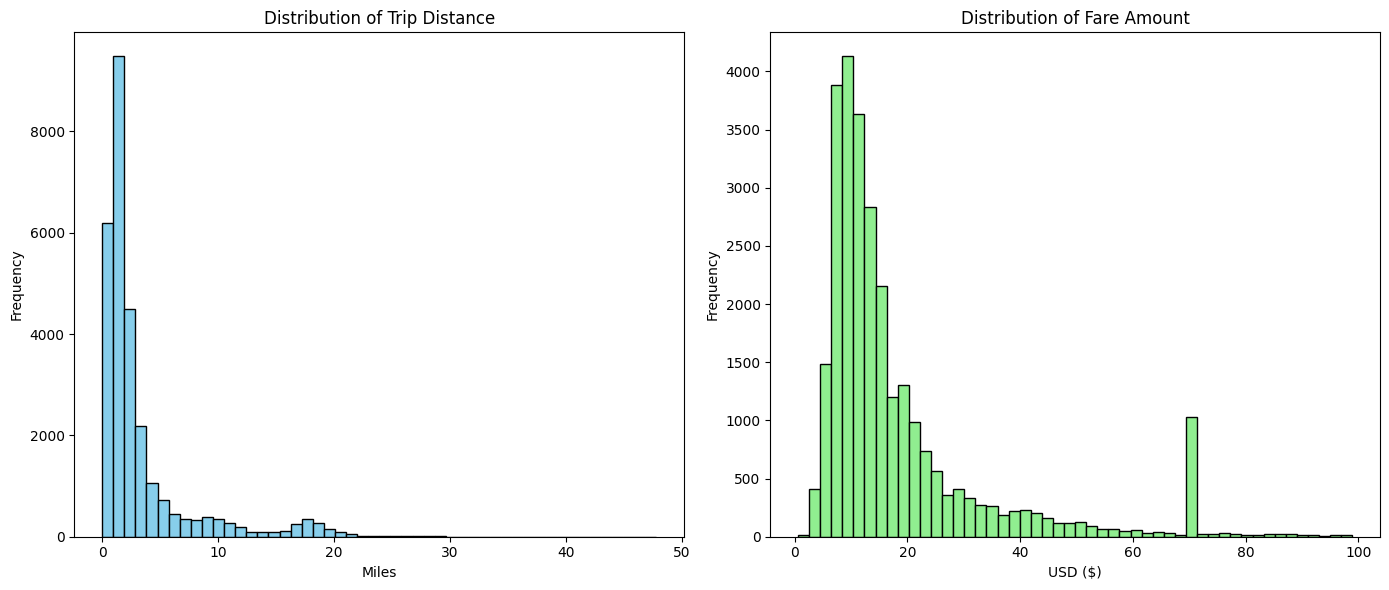

In [0]:
# 2.2 Distribution & Visualizations
import matplotlib.pyplot as plt
import pandas as pd

# 1. DO NOT re-initialize Spark if you are in a notebook. 
# Just use the existing df_final_cleaned variable.

# 2. Check if the variable actually exists to avoid the "not found" error
if 'df_final_cleaned' in locals() or 'df_final_cleaned' in globals():
    # Option A: Use the DataFrame directly (Fastest/Best practice)
    df_eda = df_eda.select("trip_distance", "fare_amount")
    
    # Option B: If you REALLY want to use SQL, register it correctly:
    # df_final_cleaned.createOrReplaceTempView("df_final_cleaned_view")
    # df_eda = spark.sql("SELECT trip_distance, fare_amount FROM df_final_cleaned_view")
else:
    print("Error: df_final_cleaned was not defined in the previous steps!")

# 3. Sampling is critical for Matplotlib
# 1% sample is roughly 28k rows - perfect for a histogram
pandas_df = df_eda.sample(fraction=0.01, seed=42).toPandas()

# 4. Plotting with better readability (higher bins)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram for 'trip_distance'
# We cap the view at 50 miles so the plot isn't squashed by outliers
axes[0].hist(pandas_df[pandas_df["trip_distance"] < 50]["trip_distance"], 
             bins=50, color='skyblue', edgecolor='black')
axes[0].set_title("Distribution of Trip Distance")
axes[0].set_xlabel("Miles")
axes[0].set_ylabel("Frequency")

# Histogram for 'fare_amount'
# We cap the view at $100 for better visualization
axes[1].hist(pandas_df[pandas_df["fare_amount"] < 100]["fare_amount"], 
             bins=50, color='lightgreen', edgecolor='black')
axes[1].set_title("Distribution of Fare Amount")
axes[1].set_xlabel("USD ($)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Section 2.3
1) Groups the dataset by number of passengers
2) Calculates average fare and average trip distance for each group
3) Counts the number of trips in each passenger group
4) Sorts results by passenger count for easy comparison
5) Displays results in a table format

In [0]:
# 2.3 grouped aggregations
from pyspark.sql.functions import avg, count, col

# Use the transformed dataframe from the previous step
df_eda = df_transformed.filter(col("trip_distance") < 800 )  # Input dataframe for EDA

# Step 1: Perform grouped aggregations
avg_fare_passenger = df_eda.groupBy("passenger_count").agg(
    avg("fare_amount").alias("avg_fare"),
    avg("trip_distance").alias("avg_distance"),
    count("*").alias("trip_count")
).orderBy("passenger_count")  # Corrected to use `orderBy`

# Step 2: Display results
avg_fare_passenger.show()

+---------------+------------------+------------------+----------+
|passenger_count|          avg_fare|      avg_distance|trip_count|
+---------------+------------------+------------------+----------+
|            1.0|18.030855959667225| 3.182873090594113|   2249849|
|            2.0|20.586651168205922| 3.825587165553436|    395093|
|            3.0|20.405823123440435|3.7016535530427386|     88966|
|            4.0|21.984088965962247|3.9901139296660815|     49592|
|            5.0|17.586557977541577| 3.090387317600434|     33306|
+---------------+------------------+------------------+----------+



In [0]:
# 2.4 Trips by VendorID
from pyspark.sql.functions import col, count, avg

# Step 1: Run the analysis
vendor_stats = df_eda.groupBy("vendorid").agg(
    count("*").alias("trip_count"),
    avg("total_amount").alias("avg_total")
).orderBy(col("trip_count").desc())  # Corrected `orderBy` syntax

# Step 2: Display the results
vendor_stats.show()

+--------+----------+------------------+
|vendorid|trip_count|         avg_total|
+--------+----------+------------------+
|       2|   2152240|27.848343744191613|
|       1|    664306|25.877433697723333|
|       6|       260|47.696269230769225|
+--------+----------+------------------+



In [0]:
# 2.4 Top Locations
top_pu = df_eda.groupBy("PULocationID").count().orderBy(col("count").desc()).limit(10)
top_do = df_eda.groupBy("DOLocationID").count().orderBy(col("count").desc()).limit(10)

print("Top 10 Pickup Locations:")
display(top_pu)
print("Top 10 Dropoff Locations:")
display(top_do)

Top 10 Pickup Locations:


PULocationID,count
161,137694
237,137261
132,136523
236,131399
162,102418
230,101177
186,100218
142,99671
138,86553
239,84703


Top 10 Dropoff Locations:


DOLocationID,count
236,136726
237,125157
161,107163
230,86047
142,85963
239,85621
170,82918
162,81577
141,80211
68,71027


Section 2.5
1) Groups the dataset by payment type and counts the number of trips in each category
2) Groups the dataset by rate code and counts the number of trips in each category
3) Sorts both results in descending order to show the most common categories first
4) Displays the distributions in table format

In [0]:
# 2.5 Payment Type & Ratecode Distribution
payment_dist = df_eda.groupBy("payment_type").count().orderBy(col("count").desc())
ratecode_dist = df_eda.groupBy("RatecodeID").count().orderBy(col("count").desc())

display(payment_dist)
display(ratecode_dist)

payment_type,count
1,2255122
2,414074
0,115229
4,22596
3,9785


RatecodeID,count
1.0,2559871
null,115229
2.0,92796
99.0,27133
5.0,8655
3.0,7085
4.0,6036
6.0,1


In [0]:
# 2.6 Simple Correlation (using Pandas sample for demo)
# Define the columns first
numerical_cols = ["trip_distance", "fare_amount", "tip_amount", "total_amount"]

# Now your original code will work
df_sample = df_eda.select(numerical_cols).sample(0.01).toPandas()
print("Sample Correlation Matrix (1% data):")
print(df_sample.corr())

print("EDA complete. Review displays for distributions, aggregates, and insights.")

Sample Correlation Matrix (1% data):
               trip_distance  fare_amount  tip_amount  total_amount
trip_distance       1.000000     0.946607    0.597154      0.937782
fare_amount         0.946607     1.000000    0.609324      0.978080
tip_amount          0.597154     0.609324    1.000000      0.733620
total_amount        0.937782     0.978080    0.733620      1.000000
EDA complete. Review displays for distributions, aggregates, and insights.


Section 2.7
1) Takes a sample of the dataset and converts it to Pandas for faster plotting
2) Creates scatter plots to examine relationships between key variables (distance, passengers, total amount) and fare
3) Adds slight random noise (jitter) to improve visibility for discrete variables like passenger count
4) Generates a correlation heatmap to show strength and direction of relationships between variables
5) Uses boxplots to analyse how fare varies across grouped passenger counts
6) Performs grouped Spark aggregations on the full dataset to analyse trends (e.g. fare by distance, fare by passengers)
7) Displays aggregated results in Databricks for easy visualisation (e.g. line charts)

Purpose?
- To explore relationships between variables and fare amount
- To identify trends, patterns, and potential correlations
- To support insights for regression modelling and further analysis

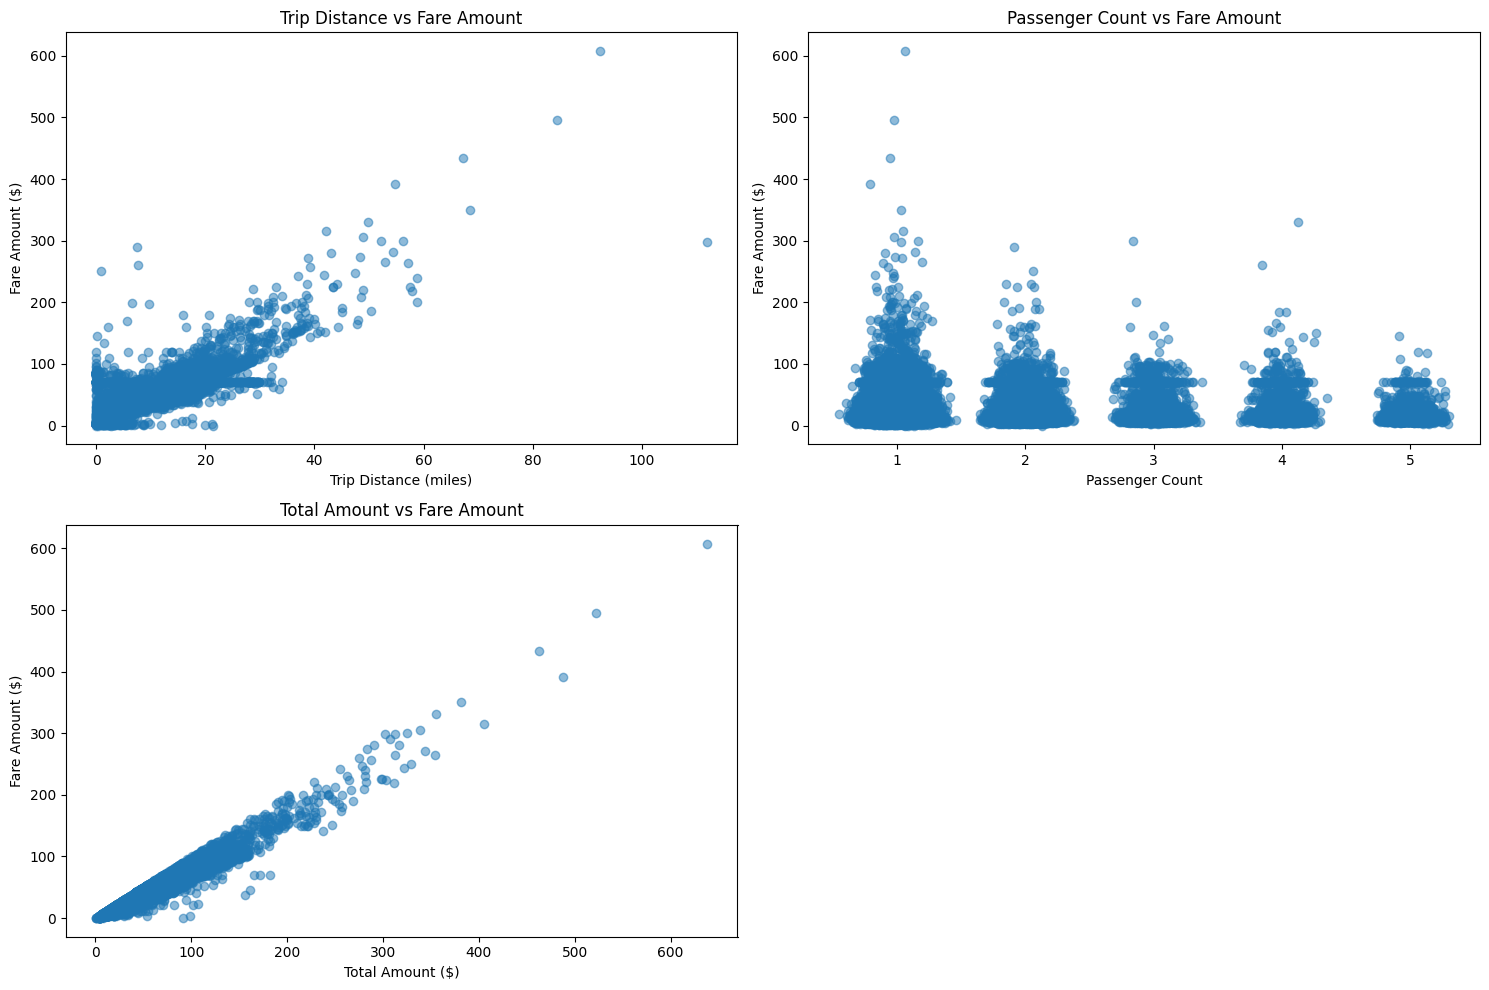

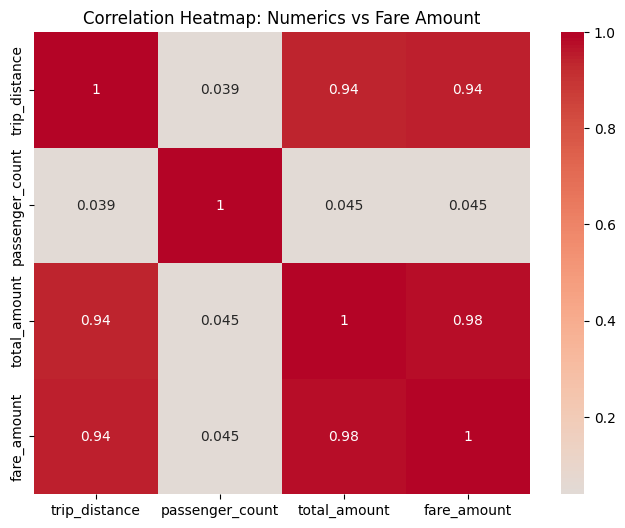

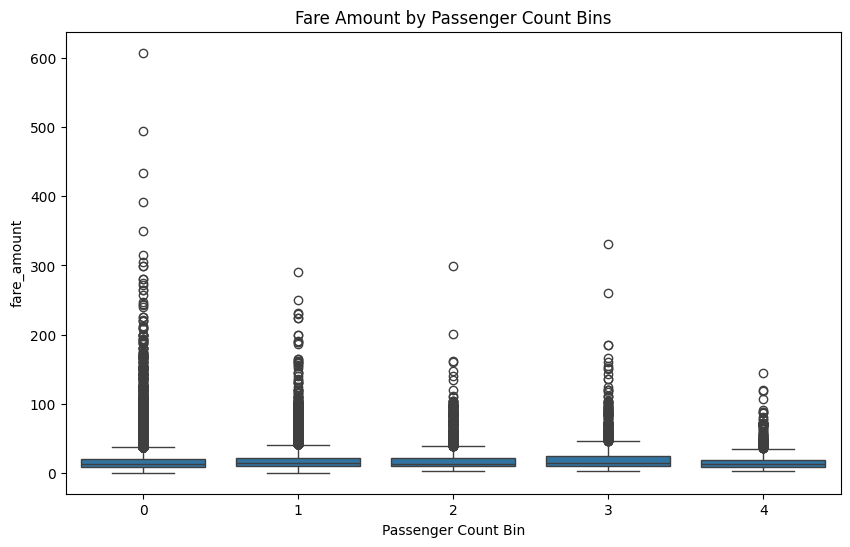

dist_bin,avg_fare,trip_count
0,7.74080347515011,651943
1,11.401592797509448,958113
2,16.215171510428803,448515
3,20.804181946368683,202829
4,24.694565129488783,103870
5,28.175132066156483,64816
6,31.401803612034282,45736
7,34.69597567778643,35852
8,37.663697019619605,40062
9,41.29343137954833,42021


passenger_count,avg_fare,trip_count
1.0,18.030855959667225,2249849
2.0,20.586651168205922,395093
3.0,20.405823123440435,88966
4.0,21.984088965962247,49592
5.0,17.586557977541577,33306


Visuals show strong positive correlation between distance/total_amount and fare; weak for passengers.


In [0]:
## 2.7 Advanced EDA: Numerical Features vs Fare Amount

# Import required
from pyspark.sql.functions import col
import pyspark.sql.functions as F
import numpy as np
import pandas as pd  # Fix for pd NameError

# Sample for plotting (Databricks handles large data via display, but sample for speed)
df_plot = df_eda.sample(0.05).toPandas()  # 5% sample ~ large enough

# 2.7.1 Scatter Plots: Key numerics vs fare_amount
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))

# Trip distance vs fare
plt.subplot(2, 2, 1)
plt.scatter(df_plot['trip_distance'], df_plot['fare_amount'], alpha=0.5)
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount ($)')
plt.title('Trip Distance vs Fare Amount')

# Passenger count vs fare (jitter for discrete)
plt.subplot(2, 2, 2)
plt.scatter(df_plot['passenger_count'] + 0.1*np.random.randn(len(df_plot)), df_plot['fare_amount'], alpha=0.5)
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount ($)')
plt.title('Passenger Count vs Fare Amount')

# Total amount vs fare (should be linear)
plt.subplot(2, 2, 3)
plt.scatter(df_plot['total_amount'], df_plot['fare_amount'], alpha=0.5)
plt.xlabel('Total Amount ($)')
plt.ylabel('Fare Amount ($)')
plt.title('Total Amount vs Fare Amount')

plt.tight_layout()
plt.show()

# 2.7.2 Correlation Heatmap
plt.figure(figsize=(8, 6))
corr_matrix = df_plot[['trip_distance', 'passenger_count', 'total_amount', 'fare_amount']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap: Numerics vs Fare Amount')
plt.show()

# 2.7.3 Boxplots: Fare by Passenger Count bins
df_plot['passenger_bin'] = pd.cut(df_plot['passenger_count'], bins=5, labels=False)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_plot, x='passenger_bin', y='fare_amount')
plt.title('Fare Amount by Passenger Count Bins')
plt.xlabel('Passenger Count Bin')
plt.show()

# 2.7.4 Spark Aggregates for Trends (full data)
fare_by_distance = df_eda.groupBy(
    F.floor("trip_distance").alias("dist_bin")
).agg(
    F.avg("fare_amount").alias("avg_fare"),
    F.count("*").alias("trip_count")
).filter(col("dist_bin") < 20).orderBy("dist_bin")

display(fare_by_distance)  # Line chart in Databricks

# Avg fare by passenger (full data)
fare_by_passenger = df_eda.groupBy("passenger_count").agg(
    F.avg("fare_amount").alias("avg_fare"),
    F.count("*").alias("trip_count")
).orderBy("passenger_count")
display(fare_by_passenger)

print("Visuals show strong positive correlation between distance/total_amount and fare; weak for passengers.")


### **Section 3: Feature Analysis & Feature Selection**
- Covers the end-to-end preparation of modelling features from the cleaned trips dataframe _**df_transformed**_, producing a final feature list (_**final_features**_) and enriched dataset (_**df_features**_) ready for model training
- Constructs seven derived features capturing temporal patterns (hour, day, month), trip behaviour (duration, speed), and categorical groupings (weekend flag, time-of-day bucket), followed by filters that remove physically implausible records
- Validates the engineered features through descriptive statistics and visualisations, grouping average revenue across time, location, and payment dimensions to confirm the features behave as expected
- Quantifies linear relationships between each feature and _**total_amount**_ via Pearson correlation, and produces a full inter-feature correlation matrix to detect any multicollinearity before modelling
- Ranks features by predictive contribution using a Random Forest regressor trained on a 10% sample, capturing non-linear signals that correlation alone would miss
- Retains all eight numeric features in the final selection, as the cost of inclusion is negligible and low-importance features may still contribute within tree-based or regularised models

In [0]:
# To display the cleaned table data from the end of Section 1
display(df_transformed.limit(5))

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,total_check,store_and_fwd_flag_bin,VendorID_indexed,RatecodeID_indexed,payment_type_indexed,VendorID_vec,RatecodeID_vec,payment_type_vec
1,2024-01-01T00:35:16.000Z,2024-01-01T01:11:52.000Z,2.0,8.2,1.0,N,246,190,1,59.0,3.5,0.5,14.15,6.94,1.0,85.09,2.5,0.0,87.59,0,1.0,0.0,0.0,"{""type"":""0"",""size"":""3"",""indices"":[""1""],""values"":[""1.0""]}","{""type"":""0"",""size"":""7"",""indices"":[""0""],""values"":[""1.0""]}","{""type"":""0"",""size"":""5"",""indices"":[""0""],""values"":[""1.0""]}"
2,2024-01-01T00:05:45.000Z,2024-01-01T00:17:29.000Z,1.0,1.06,1.0,N,246,90,2,11.4,1.0,0.5,0.0,0.0,1.0,16.4,2.5,0.0,16.4,0,0.0,0.0,1.0,"{""type"":""0"",""size"":""3"",""indices"":[""0""],""values"":[""1.0""]}","{""type"":""0"",""size"":""7"",""indices"":[""0""],""values"":[""1.0""]}","{""type"":""0"",""size"":""5"",""indices"":[""1""],""values"":[""1.0""]}"
1,2024-01-01T00:20:39.000Z,2024-01-01T00:33:30.000Z,2.0,2.1,1.0,N,79,170,1,12.8,3.5,0.5,0.0,0.0,1.0,17.8,2.5,0.0,20.3,0,1.0,0.0,0.0,"{""type"":""0"",""size"":""3"",""indices"":[""1""],""values"":[""1.0""]}","{""type"":""0"",""size"":""7"",""indices"":[""0""],""values"":[""1.0""]}","{""type"":""0"",""size"":""5"",""indices"":[""0""],""values"":[""1.0""]}"
2,2024-01-01T00:47:21.000Z,2024-01-01T00:51:58.000Z,2.0,1.13,1.0,N,238,166,1,7.9,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.0,15.48,0,0.0,0.0,0.0,"{""type"":""0"",""size"":""3"",""indices"":[""0""],""values"":[""1.0""]}","{""type"":""0"",""size"":""7"",""indices"":[""0""],""values"":[""1.0""]}","{""type"":""0"",""size"":""5"",""indices"":[""0""],""values"":[""1.0""]}"
2,2024-01-01T00:27:18.000Z,2024-01-01T00:51:09.000Z,1.0,3.47,1.0,N,13,246,2,24.7,1.0,0.5,0.0,0.0,1.0,29.7,2.5,0.0,29.7,0,0.0,0.0,1.0,"{""type"":""0"",""size"":""3"",""indices"":[""0""],""values"":[""1.0""]}","{""type"":""0"",""size"":""7"",""indices"":[""0""],""values"":[""1.0""]}","{""type"":""0"",""size"":""5"",""indices"":[""1""],""values"":[""1.0""]}"


In [0]:
# To display the number and rows from the cleaned table data from Section 1
print("Number of rows:", df_transformed.count())
print("Number of columns:", len(df_eda.columns))

Number of rows: 2816831
Number of columns: 27


In [0]:
# To display the column names from the cleaned table data from Section 1
print(df_transformed.columns)

['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'total_check', 'store_and_fwd_flag_bin', 'VendorID_indexed', 'RatecodeID_indexed', 'payment_type_indexed', 'VendorID_vec', 'RatecodeID_vec', 'payment_type_vec']


### Section 3.1 - Feature Engineering
- Imports col, when, hour, dayofweek, and month from pyspark.sql.functions
- Chains seven withColumn transformations on df_transformed to create new features in a single pass
- Extracts pickup_hour, pickup_dayofweek, and pickup_month from the pickup timestamp using built-in Spark date functions
- Computes trip_duration_min by casting both datetime columns to Unix seconds, subtracting them, and dividing by 60
- Computes speed_mph as distance divided by duration in hours, with a when guard returning 0 if duration is zero
- Creates is_weekend as a binary flag using isin([1, 7]) to identify Sunday and Saturday
- Creates time_of_day as a string label using nested when / otherwise conditions bucketing hours into morning, afternoon, evening, and night
- Applies three row-level filters to remove zero/negative durations, trips over 300 minutes, and speeds over 100 mph
- Selects a fixed list of 18 columns to produce the final df_features dataframe
- Prints a record count and displays the first 10 rows with display()

In [0]:
## ============================================================
## 3.1 — FEATURE ENGINEERING
## Uses existing df_transformed directly from Section 1
## ============================================================

from pyspark.sql.functions import col, when, hour, dayofweek, month

# Create derived features from original datetime and trip columns
df_features = df_transformed \
    .withColumn("pickup_hour", hour(col("tpep_pickup_datetime"))) \
    .withColumn("pickup_dayofweek", dayofweek(col("tpep_pickup_datetime"))) \
    .withColumn("pickup_month", month(col("tpep_pickup_datetime"))) \
    .withColumn(
        "trip_duration_min",
        (col("tpep_dropoff_datetime").cast("long") -
         col("tpep_pickup_datetime").cast("long")) / 60.0
    ) \
    .withColumn(
        "speed_mph",
        when(
            col("trip_duration_min") > 0,
            col("trip_distance") / (col("trip_duration_min") / 60.0)
        ).otherwise(0)
    ) \
    .withColumn(
        "is_weekend",
        when(col("pickup_dayofweek").isin([1, 7]), 1).otherwise(0)
    ) \
    .withColumn(
        "time_of_day",
        when((col("pickup_hour") >= 6) & (col("pickup_hour") < 12), "morning")
        .when((col("pickup_hour") >= 12) & (col("pickup_hour") < 17), "afternoon")
        .when((col("pickup_hour") >= 17) & (col("pickup_hour") < 21), "evening")
        .otherwise("night")
    )

# Remove physically impossible trips
df_features = df_features.filter(
    (col("trip_duration_min") > 0) &
    (col("trip_duration_min") < 300) &
    (col("speed_mph") < 100)
)

# Keep required original + derived columns
selected_columns = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "passenger_count",
    "trip_distance",
    "PULocationID",
    "DOLocationID",
    "VendorID",
    "RatecodeID",
    "payment_type",
    "store_and_fwd_flag_bin",
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_month",
    "is_weekend",
    "time_of_day",
    "trip_duration_min",
    "speed_mph",
    "total_amount"
]

df_features = df_features.select(*selected_columns)

print(f"Records after feature engineering filters: {df_features.count()}")
display(df_features.limit(10))

Records after feature engineering filters: 2814187


tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,VendorID,RatecodeID,payment_type,store_and_fwd_flag_bin,pickup_hour,pickup_dayofweek,pickup_month,is_weekend,time_of_day,trip_duration_min,speed_mph,total_amount
2024-01-01T00:35:16.000Z,2024-01-01T01:11:52.000Z,2.0,8.2,246,190,1,1.0,1,0,0,2,1,0,night,36.6,13.442622950819672,85.09
2024-01-01T00:05:45.000Z,2024-01-01T00:17:29.000Z,1.0,1.06,246,90,2,1.0,2,0,0,2,1,0,night,11.733333333333333,5.420454545454546,16.4
2024-01-01T00:20:39.000Z,2024-01-01T00:33:30.000Z,2.0,2.1,79,170,1,1.0,1,0,0,2,1,0,night,12.85,9.805447470817121,17.8
2024-01-01T00:47:21.000Z,2024-01-01T00:51:58.000Z,2.0,1.13,238,166,2,1.0,1,0,0,2,1,0,night,4.616666666666666,14.685920577617328,15.48
2024-01-01T00:27:18.000Z,2024-01-01T00:51:09.000Z,1.0,3.47,13,246,2,1.0,2,0,0,2,1,0,night,23.85,8.729559748427674,29.7
2024-01-01T00:29:55.000Z,2024-01-01T00:43:30.000Z,2.0,2.3,229,79,1,1.0,1,0,0,2,1,0,night,13.583333333333334,10.159509202453988,22.7
2024-01-01T00:44:23.000Z,2024-01-01T00:50:21.000Z,3.0,1.8,50,239,1,1.0,2,0,0,2,1,0,night,5.966666666666667,18.100558659217878,15.0
2024-01-01T00:52:26.000Z,2024-01-01T00:55:08.000Z,4.0,0.6,239,143,1,1.0,2,0,0,2,1,0,night,2.7,13.333333333333332,10.8
2024-01-01T00:30:54.000Z,2024-01-01T00:39:47.000Z,1.0,1.54,114,234,2,1.0,1,0,0,2,1,0,night,8.883333333333333,10.401500938086304,18.84
2024-01-01T00:19:51.000Z,2024-01-01T00:53:49.000Z,3.0,3.43,246,239,2,1.0,2,0,0,2,1,0,night,33.96666666666667,6.058881256133464,36.7


In [0]:
print(df_features.columns)

['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'PULocationID', 'DOLocationID', 'VendorID', 'RatecodeID', 'payment_type', 'store_and_fwd_flag_bin', 'pickup_hour', 'pickup_dayofweek', 'pickup_month', 'is_weekend', 'time_of_day', 'trip_duration_min', 'speed_mph', 'total_amount']


### Original columns
- "tpep_pickup_datetime"
- "tpep_dropoff_datetime"
- "passenger_count"
- "trip_distance"
- "PULocationID"
- "DOLocationID"
- "VendorID"
- "RatecodeID"
- "payment_type"
- "store_and_fwd_flag"
- "total_amount"

### Feature Engineered Columns (Added)
- "pickup_hour"
- "pickup_dayofweek"
- "pickup_month"
- "trip_duration_min"
- "speed_mph"
- "is_weekend"
- "time_of_day"

### Section 3.2 - Exploratory Feature Analysis
- Imports avg and count from pyspark.sql.functions, plus matplotlib and pandas
- Defines a list of numeric features and filters it to only columns that exist in df_features
- Runs describe() on all numeric features plus the target to print summary statistics
- Groups by time_of_day, pickup_hour, pickup_dayofweek, is_weekend, pickup_month, PULocationID, and payment_type separately, computing average revenue, average distance, and trip count for each
- Filters pickup zone groups to locations with over 500 trips before ranking the top 15 by average revenue
- Draws a 1% random sample into Pandas using sample(False, 0.01, seed=42) for use in plots
- Converts all grouped Spark dataframes to Pandas with toPandas()
- Plots histograms for trip distance, duration, speed, and total amount
- Plots bar charts for time of day, day of week, month, weekend indicator, and payment type
- Plots a line chart of average revenue across all 24 pickup hours
- Plots a horizontal bar chart of the top 15 high-revenue pickup zones
- Plots scatter plots of trip distance vs total amount and trip duration vs total amount

=== Summary Statistics ===
+-------+------------------+------------------+-----------------+------------------+-------------------+-------------------+--------------------+--------------------+------------------+
|summary|   passenger_count|     trip_distance|      pickup_hour|  pickup_dayofweek|       pickup_month|         is_weekend|   trip_duration_min|           speed_mph|      total_amount|
+-------+------------------+------------------+-----------------+------------------+-------------------+-------------------+--------------------+--------------------+------------------+
|  count|           2814187|           2814187|          2814187|           2814187|            2814187|            2814187|             2814187|             2814187|           2814187|
|   mean| 1.303377494103981|3.3006594373437586|14.21609047302116|  4.07471394047375| 1.0000401536927006|0.25576125538210503|  14.991717566506281|   11.52716467581763|27.374917594318962|
| stddev|0.7221439418125077| 4.399064300408

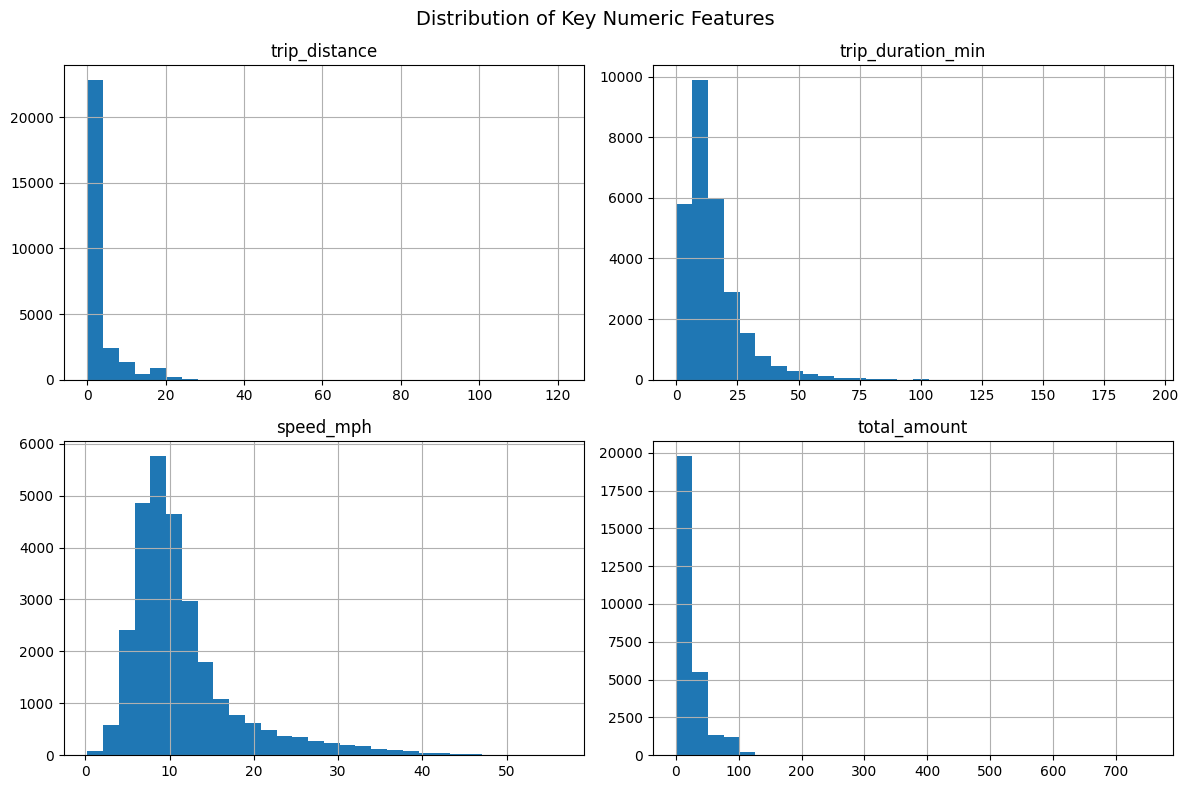

=== Plotting Average Revenue by Time of Day ===


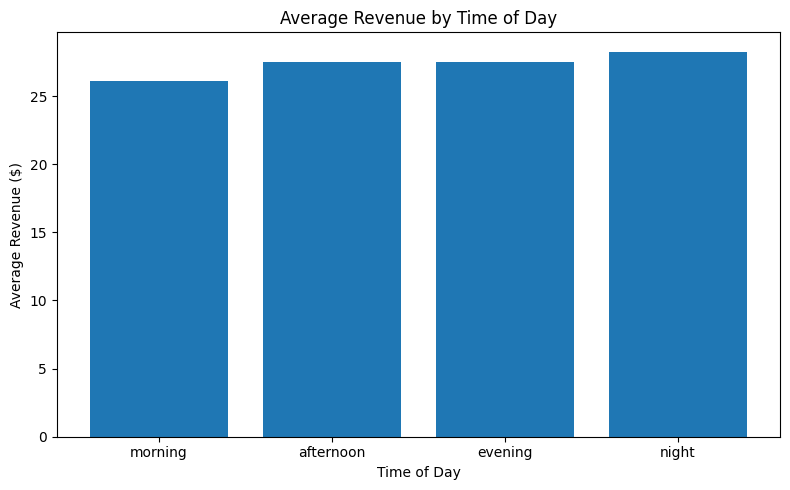

=== Plotting Average Revenue by Pickup Hour ===


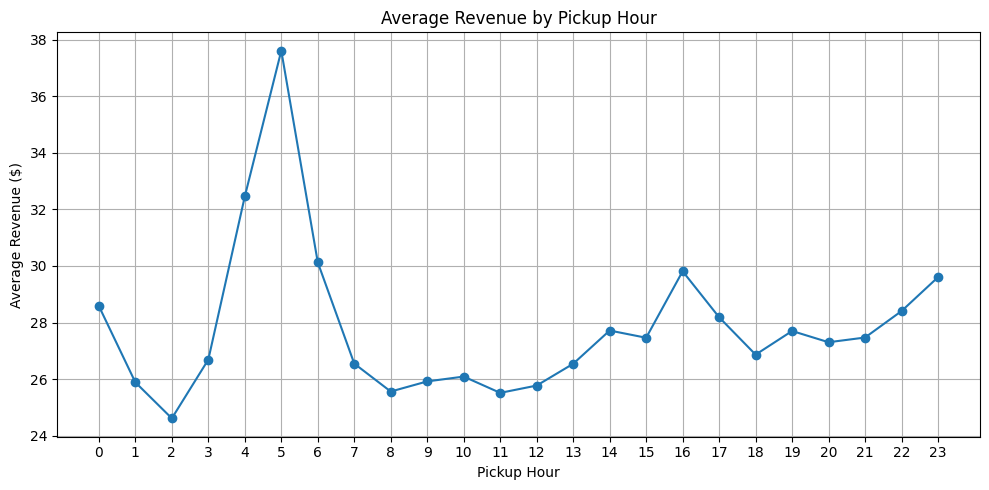

=== Plotting Average Revenue by Day of Week ===


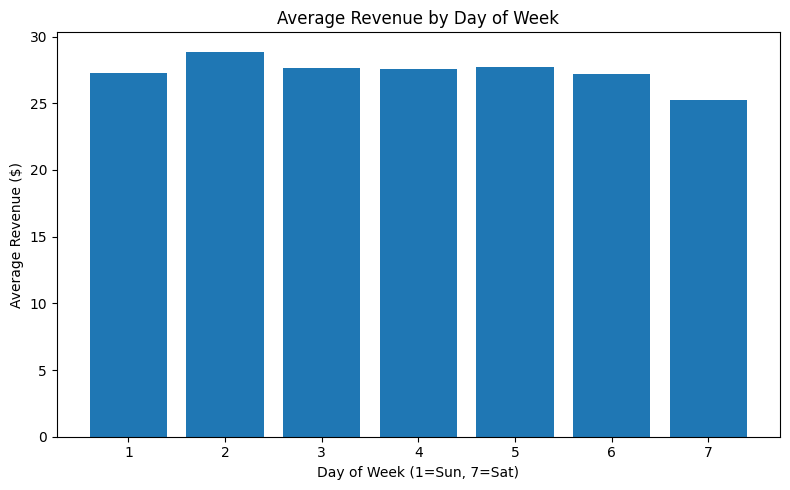

=== Plotting Weekend vs Weekday Revenue ===


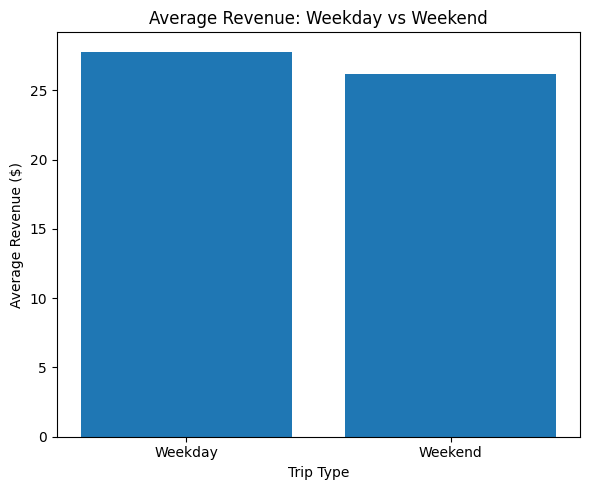

=== Plotting Average Revenue by Pickup Month ===


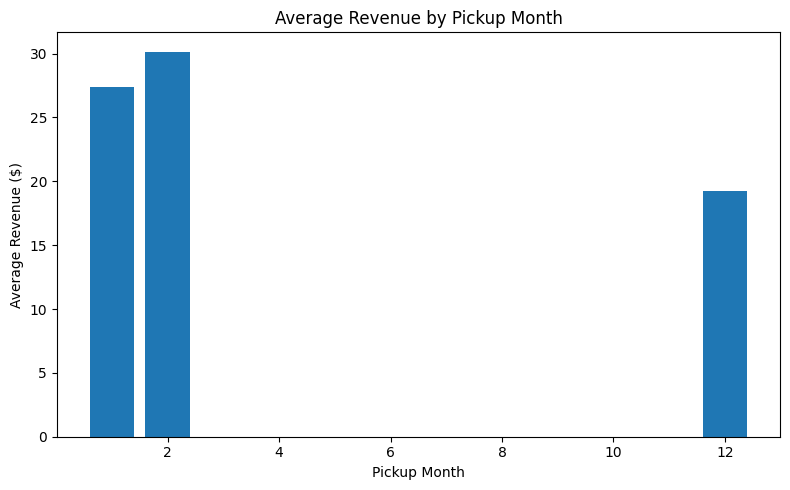

=== Plotting Trip Distance vs Total Amount ===


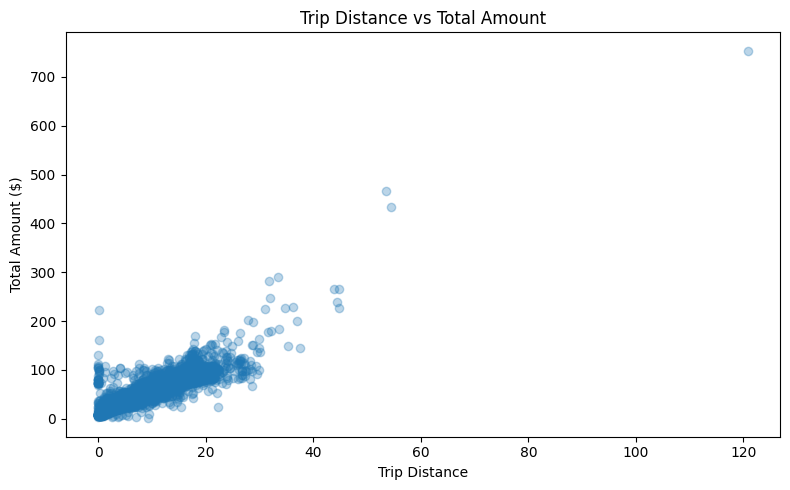

=== Plotting Trip Duration vs Total Amount ===


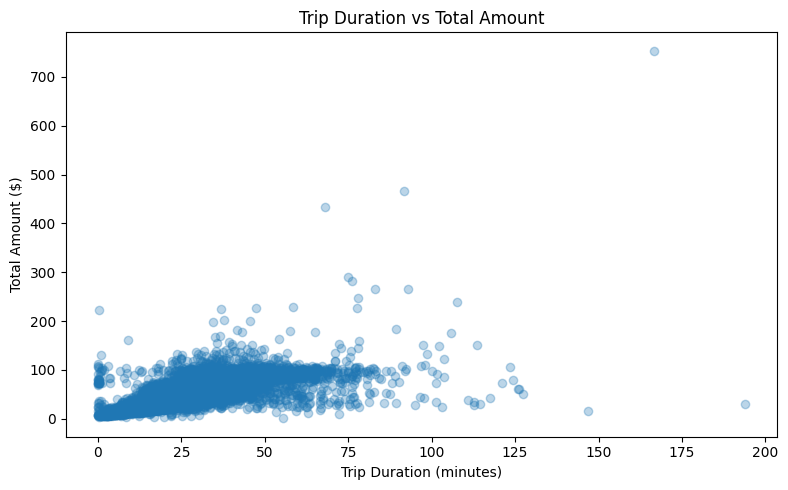

=== Plotting Top 15 Pickup Zones by Revenue ===


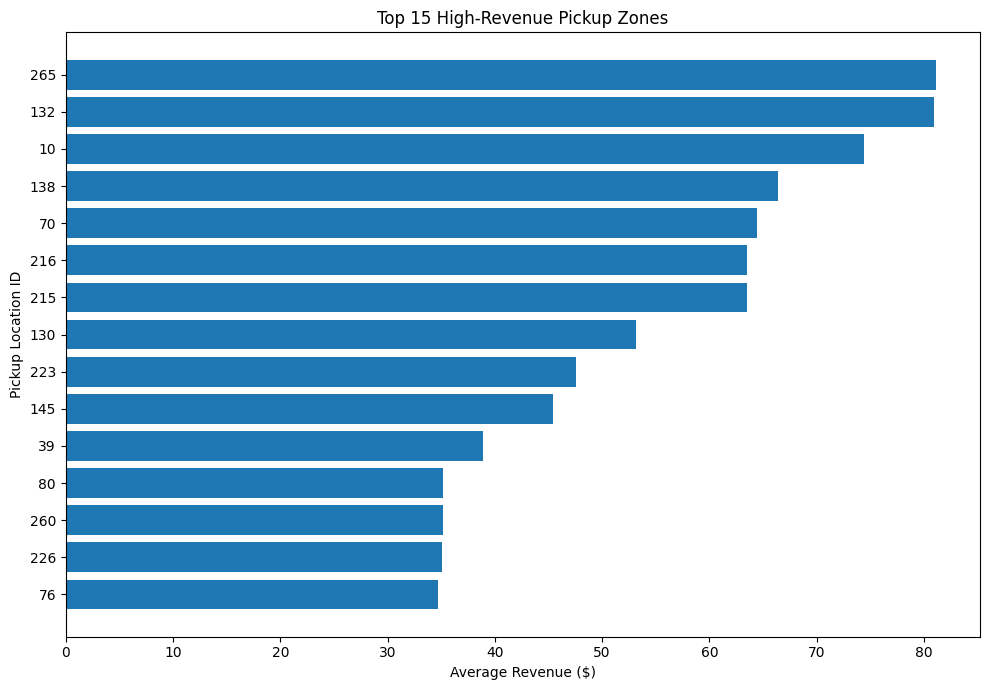

=== Plotting Average Revenue by Payment Type ===


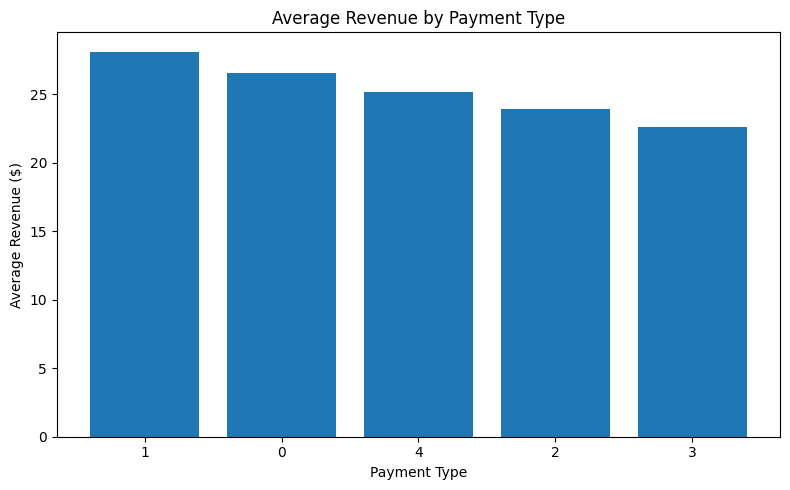

In [0]:
## ============================================================
## 3.2 — EXPLORATORY FEATURE ANALYSIS
## Understand distributions and relationships with total_amount
## Input:  df_features  (from Section 3.1)
## ============================================================

from pyspark.sql.functions import col, avg, count
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------------------------
# 3.2.0 Define numeric features
# ------------------------------------------------------------
numeric_features = [
    "passenger_count",
    "trip_distance",
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_month",
    "is_weekend",
    "trip_duration_min",
    "speed_mph"
]

# Safety check: keep only columns that actually exist
numeric_features = [c for c in numeric_features if c in df_features.columns]

# ------------------------------------------------------------
# 3.2.1 Summary statistics
# ------------------------------------------------------------
print("=== Summary Statistics ===")
df_features.select(numeric_features + ["total_amount"]).describe().show()

# ------------------------------------------------------------
# 3.2.2 Revenue by time-of-day segment
# ------------------------------------------------------------
print("=== Avg Revenue by Time of Day ===")
df_timeofday = df_features.groupBy("time_of_day") \
    .agg(
        avg("total_amount").alias("avg_revenue"),
        avg("trip_distance").alias("avg_distance"),
        avg("trip_duration_min").alias("avg_duration_min"),
        count("*").alias("trip_count")
    ) \
    .orderBy("avg_revenue", ascending=False)

df_timeofday.show()

# ------------------------------------------------------------
# 3.2.3 Revenue by pickup hour
# ------------------------------------------------------------
print("=== Avg Revenue by Hour ===")
df_hour = df_features.groupBy("pickup_hour") \
    .agg(
        avg("total_amount").alias("avg_revenue"),
        avg("trip_distance").alias("avg_distance"),
        count("*").alias("trip_count")
    ) \
    .orderBy("pickup_hour")

df_hour.show(24)

# ------------------------------------------------------------
# 3.2.4 Revenue by day of week
# ------------------------------------------------------------
print("=== Avg Revenue by Day of Week (1=Sun, 7=Sat) ===")
df_day = df_features.groupBy("pickup_dayofweek") \
    .agg(
        avg("total_amount").alias("avg_revenue"),
        avg("trip_distance").alias("avg_distance"),
        count("*").alias("trip_count")
    ) \
    .orderBy("pickup_dayofweek")

df_day.show()

# ------------------------------------------------------------
# 3.2.5 Revenue by weekend vs weekday
# ------------------------------------------------------------
print("=== Avg Revenue by Weekend Indicator ===")
df_weekend = df_features.groupBy("is_weekend") \
    .agg(
        avg("total_amount").alias("avg_revenue"),
        avg("trip_distance").alias("avg_distance"),
        count("*").alias("trip_count")
    ) \
    .orderBy("is_weekend")

df_weekend.show()

# ------------------------------------------------------------
# 3.2.6 Revenue by pickup month
# ------------------------------------------------------------
print("=== Avg Revenue by Pickup Month ===")
df_month = df_features.groupBy("pickup_month") \
    .agg(
        avg("total_amount").alias("avg_revenue"),
        avg("trip_distance").alias("avg_distance"),
        count("*").alias("trip_count")
    ) \
    .orderBy("pickup_month")

df_month.show()

# ------------------------------------------------------------
# 3.2.7 Top 15 high-revenue pickup zones
# ------------------------------------------------------------
print("=== Top 15 High-Revenue Pickup Zones ===")
df_zones = df_features.groupBy("PULocationID") \
    .agg(
        avg("total_amount").alias("avg_revenue"),
        count("*").alias("trip_count")
    ) \
    .filter(col("trip_count") > 500) \
    .orderBy("avg_revenue", ascending=False) \
    .limit(15)

df_zones.show()

# ------------------------------------------------------------
# 3.2.8 Revenue by payment type
# ------------------------------------------------------------
print("=== Avg Revenue by Payment Type ===")
df_payment = df_features.groupBy("payment_type") \
    .agg(
        avg("total_amount").alias("avg_revenue"),
        count("*").alias("trip_count")
    ) \
    .orderBy("avg_revenue", ascending=False)

df_payment.show()

# ------------------------------------------------------------
# 3.2.9 Convert selected data to Pandas for plotting
# Use a sample for scatter plots / histograms for speed
# ------------------------------------------------------------
df_sample = df_features.select(
    "trip_distance",
    "trip_duration_min",
    "speed_mph",
    "total_amount"
).sample(False, 0.01, seed=42).toPandas()

timeofday_pd = df_timeofday.toPandas()
hour_pd = df_hour.toPandas()
day_pd = df_day.toPandas()
weekend_pd = df_weekend.toPandas()
month_pd = df_month.toPandas()
zones_pd = df_zones.toPandas()
payment_pd = df_payment.toPandas()

# ------------------------------------------------------------
# 3.2.10 Histograms for key numeric variables
# ------------------------------------------------------------
print("=== Plotting Histograms ===")

hist_cols = ["trip_distance", "trip_duration_min", "speed_mph", "total_amount"]
df_sample[hist_cols].hist(figsize=(12, 8), bins=30)

plt.suptitle("Distribution of Key Numeric Features", fontsize=14)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3.2.11 Bar chart: Average revenue by time of day
# ------------------------------------------------------------
print("=== Plotting Average Revenue by Time of Day ===")

timeofday_order = ["morning", "afternoon", "evening", "night"]
timeofday_pd["time_of_day"] = pd.Categorical(
    timeofday_pd["time_of_day"],
    categories=timeofday_order,
    ordered=True
)
timeofday_pd = timeofday_pd.sort_values("time_of_day")

plt.figure(figsize=(8, 5))
plt.bar(timeofday_pd["time_of_day"], timeofday_pd["avg_revenue"])
plt.title("Average Revenue by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Average Revenue ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3.2.12 Line chart: Average revenue by pickup hour
# ------------------------------------------------------------
print("=== Plotting Average Revenue by Pickup Hour ===")

plt.figure(figsize=(10, 5))
plt.plot(hour_pd["pickup_hour"], hour_pd["avg_revenue"], marker="o")
plt.title("Average Revenue by Pickup Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Average Revenue ($)")
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3.2.13 Bar chart: Average revenue by day of week
# ------------------------------------------------------------
print("=== Plotting Average Revenue by Day of Week ===")

plt.figure(figsize=(8, 5))
plt.bar(day_pd["pickup_dayofweek"], day_pd["avg_revenue"])
plt.title("Average Revenue by Day of Week")
plt.xlabel("Day of Week (1=Sun, 7=Sat)")
plt.ylabel("Average Revenue ($)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3.2.14 Bar chart: Weekend vs Weekday revenue
# ------------------------------------------------------------
print("=== Plotting Weekend vs Weekday Revenue ===")

weekend_pd = weekend_pd.sort_values("is_weekend")
weekend_labels = ["Weekday", "Weekend"]

plt.figure(figsize=(6, 5))
plt.bar(weekend_labels, weekend_pd["avg_revenue"])
plt.title("Average Revenue: Weekday vs Weekend")
plt.xlabel("Trip Type")
plt.ylabel("Average Revenue ($)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3.2.15 Bar chart: Average revenue by pickup month
# ------------------------------------------------------------
print("=== Plotting Average Revenue by Pickup Month ===")

plt.figure(figsize=(8, 5))
plt.bar(month_pd["pickup_month"], month_pd["avg_revenue"])
plt.title("Average Revenue by Pickup Month")
plt.xlabel("Pickup Month")
plt.ylabel("Average Revenue ($)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3.2.16 Scatter plot: Trip distance vs total amount
# ------------------------------------------------------------
print("=== Plotting Trip Distance vs Total Amount ===")

plt.figure(figsize=(8, 5))
plt.scatter(df_sample["trip_distance"], df_sample["total_amount"], alpha=0.3)
plt.title("Trip Distance vs Total Amount")
plt.xlabel("Trip Distance")
plt.ylabel("Total Amount ($)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3.2.17 Scatter plot: Trip duration vs total amount
# ------------------------------------------------------------
print("=== Plotting Trip Duration vs Total Amount ===")

plt.figure(figsize=(8, 5))
plt.scatter(df_sample["trip_duration_min"], df_sample["total_amount"], alpha=0.3)
plt.title("Trip Duration vs Total Amount")
plt.xlabel("Trip Duration (minutes)")
plt.ylabel("Total Amount ($)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3.2.18 Horizontal bar chart: Top 15 pickup zones by revenue
# ------------------------------------------------------------
print("=== Plotting Top 15 Pickup Zones by Revenue ===")

zones_pd = zones_pd.sort_values("avg_revenue", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(zones_pd["PULocationID"].astype(str), zones_pd["avg_revenue"])
plt.title("Top 15 High-Revenue Pickup Zones")
plt.xlabel("Average Revenue ($)")
plt.ylabel("Pickup Location ID")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3.2.19 Bar chart: Average revenue by payment type
# ------------------------------------------------------------
print("=== Plotting Average Revenue by Payment Type ===")

payment_pd["payment_type"] = payment_pd["payment_type"].astype(str)

plt.figure(figsize=(8, 5))
plt.bar(payment_pd["payment_type"], payment_pd["avg_revenue"])
plt.title("Average Revenue by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Average Revenue ($)")
plt.tight_layout()
plt.show()

### Section 3.3 - Correlation Analysis
- Imports VectorAssembler and Correlation from pyspark.ml, plus numpy and seaborn
- Redefines and safety-checks the numeric feature list against available columns in df_features
- Computes pairwise Pearson correlation between each feature and total_amount using df_features.stat.corr()
- Collects results into a Pandas dataframe, adds an absolute value column, sorts by strength, and drops the helper column before printing
- Assembles all features plus the target into a single vector column using VectorAssembler with handleInvalid="skip"
- Passes the vector dataframe to Correlation.corr() to compute the full 9×9 matrix in a distributed fashion
- Converts the correlation matrix to a Pandas dataframe with feature names as both index and columns
- Renders a lower-triangle heatmap using seaborn with RdYlGn colouring, centred at zero, with cell annotations
- Saves the heatmap to /tmp/correlation_heatmap.png at 150 dpi

=== Pearson Correlation with total_amount ===
          Feature  Correlation
    trip_distance       0.9368
trip_duration_min       0.7839
        speed_mph       0.6618
  passenger_count       0.0445
       is_weekend      -0.0330
 pickup_dayofweek      -0.0319
      pickup_hour       0.0201
     pickup_month      -0.0007


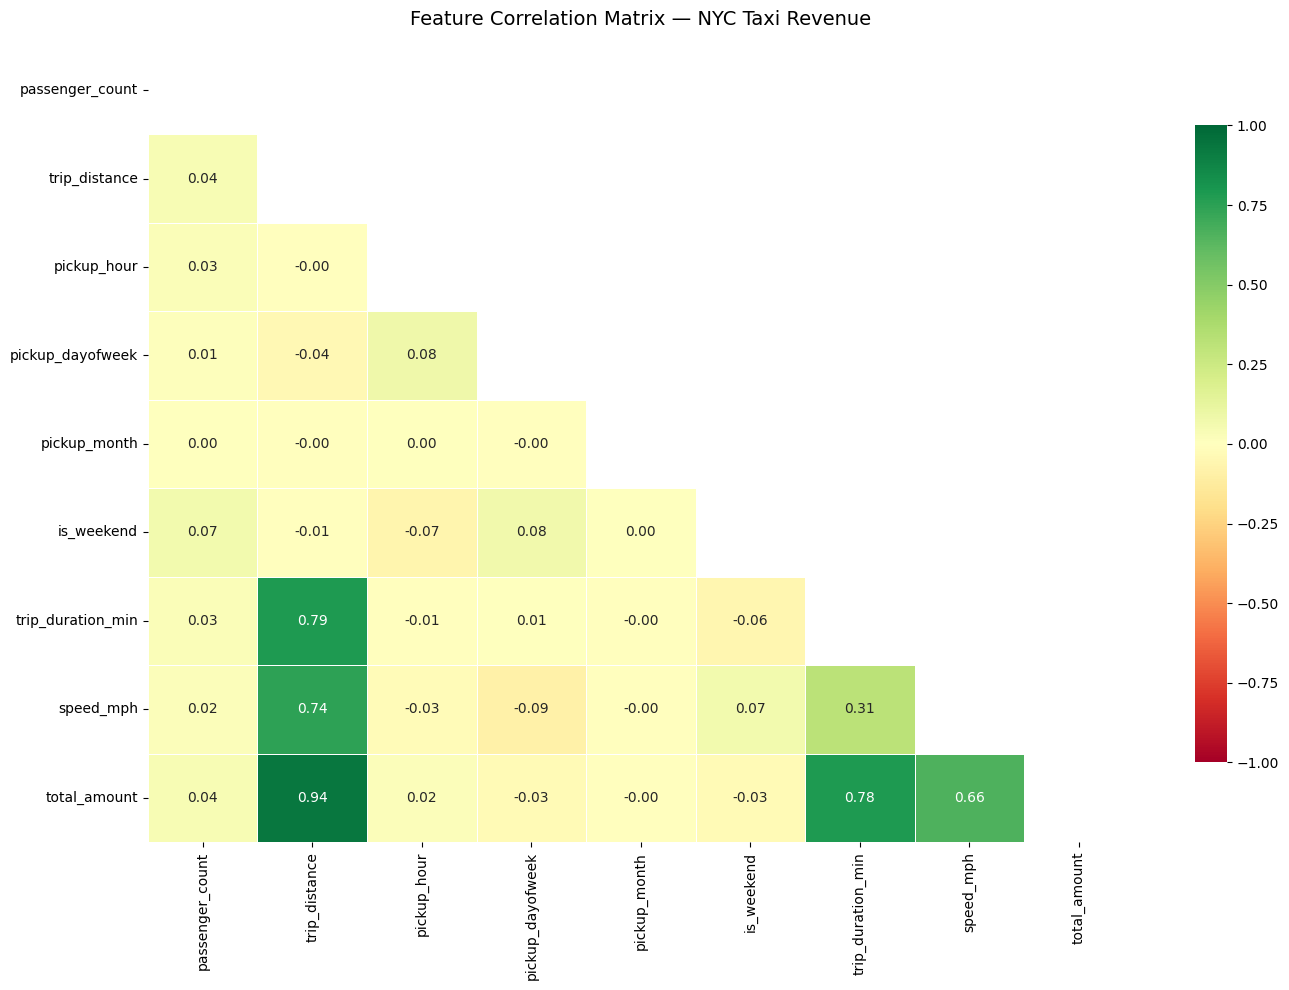

Saved: /tmp/correlation_heatmap.png


In [0]:
## ============================================================
## 3.3 — CORRELATION ANALYSIS
## ============================================================

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import builtins

# Selected numeric features (clean + meaningful)
numeric_features = [
    "passenger_count",
    "trip_distance",
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_month",
    "is_weekend",
    "trip_duration_min",
    "speed_mph"
]

# Safety check (ensures columns exist)
numeric_features = [col for col in numeric_features if col in df_features.columns]

# ============================================================
# 3.3.1 Pearson correlation with target (total_amount)
# ============================================================
print("=== Pearson Correlation with total_amount ===")

correlations = {}

for feature in numeric_features:
    corr_val = df_features.stat.corr(feature, "total_amount")
    correlations[feature] = builtins.round(corr_val, 4) if corr_val is not None else None

corr_df = pd.DataFrame(
    list(correlations.items()), columns=["Feature", "Correlation"]
)

# Sort by strongest relationship
corr_df["Abs_Correlation"] = corr_df["Correlation"].abs()
corr_df = corr_df.sort_values("Abs_Correlation", ascending=False)\
                 .drop(columns=["Abs_Correlation"])

print(corr_df.to_string(index=False))

# ============================================================
# 3.3.2 Full correlation matrix
# ============================================================
corr_features = numeric_features + ["total_amount"]

assembler_corr = VectorAssembler(
    inputCols=corr_features,
    outputCol="corr_features_vec",
    handleInvalid="skip"
)

df_corr_vec = assembler_corr.transform(df_features).select("corr_features_vec")

corr_matrix = Correlation.corr(df_corr_vec, "corr_features_vec").head()[0]
corr_array = np.array(corr_matrix.toArray())

corr_pd = pd.DataFrame(
    corr_array,
    index=corr_features,
    columns=corr_features
)

# ============================================================
# 3.3.3 Heatmap
# ============================================================
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_pd, dtype=bool))

sns.heatmap(
    corr_pd,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Feature Correlation Matrix — NYC Taxi Revenue", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig("/tmp/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: /tmp/correlation_heatmap.png")

### Section 3.4 - Feature Importance via Random Forest
- Imports VectorAssembler, RandomForestRegressor, and Pipeline from pyspark.ml
- Defines and safety-checks the candidate feature list against available columns
- Assembles features into a vector column using VectorAssembler with handleInvalid="skip"
- Draws a 10% random sample of df_features for faster training and prints the resulting row count
- Configures a RandomForestRegressor with 100 trees, max depth 8, targeting total_amount, with a fixed seed for reproducibility
- Wraps the assembler and regressor in a Pipeline and fits it on the sample dataframe
- Extracts the fitted regressor from rf_model.stages[-1] and calls featureImportances.toArray() to retrieve scores
- Builds a Pandas dataframe pairing feature names with importance scores, sorts descending, and prints the full table
- Plots a horizontal bar chart of importances in ascending order for readability
- Saves the chart to /tmp/feature_importance.png at 150 dpi

Features used for Random Forest importance:
['passenger_count', 'trip_distance', 'pickup_hour', 'pickup_dayofweek', 'pickup_month', 'is_weekend', 'trip_duration_min', 'speed_mph']
Training RF on sample size: 281278

=== Random Forest Feature Importances ===
          Feature  Importance
    trip_distance    0.538243
trip_duration_min    0.258709
        speed_mph    0.193221
      pickup_hour    0.005976
  passenger_count    0.001997
 pickup_dayofweek    0.001045
       is_weekend    0.000809
     pickup_month    0.000000


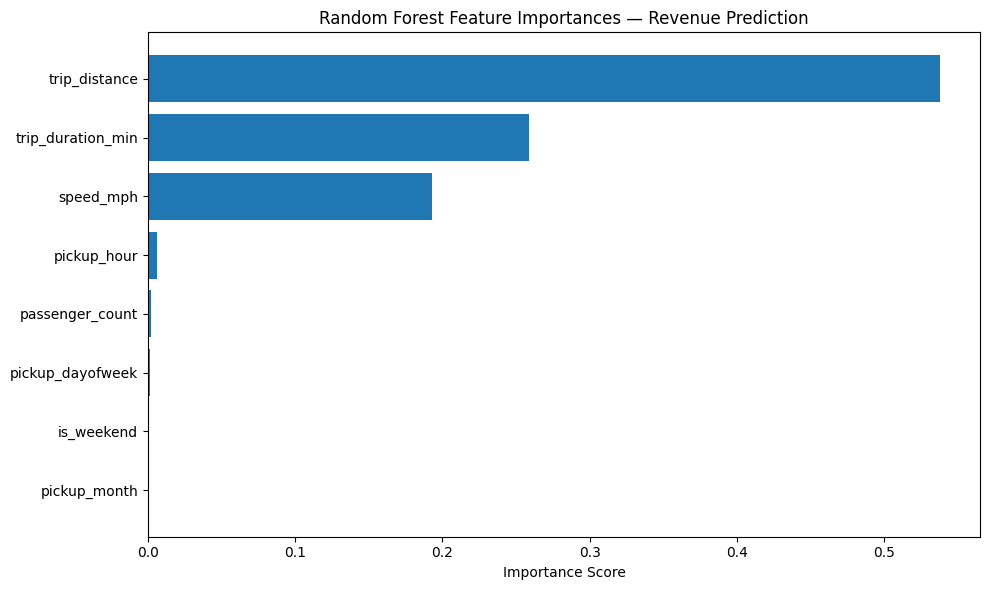

Saved: /tmp/feature_importance.png


In [0]:
## ============================================================
## 3.4 — FEATURE IMPORTANCE VIA RANDOM FOREST
## Tree-based importance captures non-linear relationships
## Input:  df_features  (from Section 3.1)
## Output: importance_df (Pandas DataFrame), importance PNG
## ============================================================

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml import Pipeline
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 3.4.1 Candidate features from df_features
# Only use numeric features that exist in df_features
# ------------------------------------------------------------
candidate_features = [
    "passenger_count",
    "trip_distance",
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_month",
    "is_weekend",
    "trip_duration_min",
    "speed_mph"
]

# Safety check
candidate_features = [c for c in candidate_features if c in df_features.columns]

print("Features used for Random Forest importance:")
print(candidate_features)

# ------------------------------------------------------------
# 3.4.2 Assemble feature vector
# ------------------------------------------------------------
assembler = VectorAssembler(
    inputCols=candidate_features,
    outputCol="features",
    handleInvalid="skip"
)

# ------------------------------------------------------------
# 3.4.3 Sample data for faster training
# ------------------------------------------------------------
df_sample = df_features.sample(False, 0.10, seed=42)
print(f"Training RF on sample size: {df_sample.count()}")

# ------------------------------------------------------------
# 3.4.4 Train Random Forest regressor
# ------------------------------------------------------------
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="total_amount",
    numTrees=100,
    maxDepth=8,
    seed=42
)

rf_pipeline = Pipeline(stages=[assembler, rf])
rf_model = rf_pipeline.fit(df_sample)

# ------------------------------------------------------------
# 3.4.5 Extract and rank feature importances
# ------------------------------------------------------------
rf_fitted = rf_model.stages[-1]
importances = rf_fitted.featureImportances.toArray()

importance_df = pd.DataFrame({
    "Feature": candidate_features,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print("\n=== Random Forest Feature Importances ===")
print(importance_df.to_string(index=False))

# ------------------------------------------------------------
# 3.4.6 Plot feature importances
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"][::-1], importance_df["Importance"][::-1])
plt.xlabel("Importance Score")
plt.title("Random Forest Feature Importances — Revenue Prediction")
plt.tight_layout()
plt.savefig("/tmp/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: /tmp/feature_importance.png")

### Section 3.5 - Feature Selection
- Imports builtins to safely use Python's built-in abs() without conflict from any Spark or pandas overrides
- Checks that importance_df exists in the global namespace and raises a ValueError with a clear message if Section 3.4 has not been run
- Defines the full list of eight candidate features and filters it to columns present in df_features
- Looks up each feature's importance score from importance_df and prints a formatted summary, noting "not available" for any missing entries
- Iterates over all unique feature pairs and computes pairwise Pearson correlation using df_features.stat.corr()
- Flags any pair with an absolute correlation above 0.90 as highly correlated and appends it to a results list
- Prints flagged pairs with their correlation values, or confirms no issues were found — in either case, no features are dropped
- Copies the full feature list to final_features and prints each entry alongside its importance score as the pipeline's final output

In [0]:
## ============================================================
## 3.5 — FEATURE SELECTION
## Keeps all selected modelling variables while still showing
## RF importance + multicollinearity diagnostics
## Input:  df_features    (from Section 3.1)
##         importance_df  (from Section 3.4)
## Output: final_features (Python list)
## ============================================================

import builtins
import pandas as pd

# ------------------------------------------------------------
# 3.5.0 Ensure importance_df exists
# ------------------------------------------------------------
if "importance_df" not in globals():
    raise ValueError("importance_df is not defined. Please run Section 3.4 first.")

# ------------------------------------------------------------
# 3.5.1 Define the full feature set to retain
# ------------------------------------------------------------
all_required_features = [
    "passenger_count",
    "trip_distance",
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_month",
    "is_weekend",
    "trip_duration_min",
    "speed_mph"
]

# Safety check: only keep columns that actually exist
all_required_features = [f for f in all_required_features if f in df_features.columns]

# ------------------------------------------------------------
# 3.5.2 Show Random Forest importance for all required features
# ------------------------------------------------------------
print("\n=== Random Forest Importance Scores ===")

imp_lookup = importance_df.set_index("Feature")["Importance"]

for f in all_required_features:
    score = imp_lookup.get(f, None)
    if pd.notna(score):
        print(f"  {f:25s}  {score:.4f}")
    else:
        print(f"  {f:25s}  not available")

# ------------------------------------------------------------
# 3.5.3 Multicollinearity check (diagnostic only)
# ------------------------------------------------------------
print("\n=== Checking multicollinearity among retained features ===")

high_corr_pairs = []

for i, f1 in enumerate(all_required_features):
    for f2 in all_required_features[i + 1:]:
        corr_val = df_features.stat.corr(f1, f2)
        if corr_val is not None:
            r = builtins.abs(corr_val)
            if r > 0.90:
                high_corr_pairs.append((f1, f2, round(r, 4)))

if high_corr_pairs:
    print("Highly correlated pairs found (|r| > 0.90):")
    for f1, f2, r in high_corr_pairs:
        print(f"  {f1}  <->  {f2}  :  r = {r}")
    print("Note: These are reported for interpretation only; no features are dropped.")
else:
    print("  None found — no serious multicollinearity issues detected.")

# ------------------------------------------------------------
# 3.5.4 Final feature list
# ------------------------------------------------------------
final_features = all_required_features.copy()

# ------------------------------------------------------------
# 3.5.5 Print final selected features
# ------------------------------------------------------------
print(f"\n=== FINAL SELECTED FEATURES ({len(final_features)} total) ===")

for f in final_features:
    score = imp_lookup.get(f, None)
    if pd.notna(score):
        print(f"  {f:25s}  importance: {score:.4f}")
    else:
        print(f"  {f:25s}  importance: not available")


=== Random Forest Importance Scores ===
  passenger_count            0.0020
  trip_distance              0.5382
  pickup_hour                0.0060
  pickup_dayofweek           0.0010
  pickup_month               0.0000
  is_weekend                 0.0008
  trip_duration_min          0.2587
  speed_mph                  0.1932

=== Checking multicollinearity among retained features ===
  None found — no serious multicollinearity issues detected.

=== FINAL SELECTED FEATURES (8 total) ===
  passenger_count            importance: 0.0020
  trip_distance              importance: 0.5382
  pickup_hour                importance: 0.0060
  pickup_dayofweek           importance: 0.0010
  pickup_month               importance: 0.0000
  is_weekend                 importance: 0.0008
  trip_duration_min          importance: 0.2587
  speed_mph                  importance: 0.1932


In [0]:
df_ml = df_features.select(final_features + ["total_amount"])

print(f"Records after feature engineering filters: {df_ml.count()}")
display(df_ml.limit(5))

Records after feature engineering filters: 2814187


passenger_count,trip_distance,pickup_hour,pickup_dayofweek,pickup_month,is_weekend,trip_duration_min,speed_mph,total_amount
2.0,8.2,0,2,1,0,36.6,13.442622950819672,85.09
1.0,1.06,0,2,1,0,11.733333333333333,5.420454545454546,16.4
2.0,2.1,0,2,1,0,12.85,9.805447470817121,17.8
2.0,1.13,0,2,1,0,4.616666666666666,14.685920577617328,15.48
1.0,3.47,0,2,1,0,23.85,8.729559748427674,29.7


#Section 4: Machine Learning Algorithm - Revenue Model
- Apply machine learning model to the dataset: linear regression and random forest 
- Evaluate the model result with r2, mae, rmse

In [0]:
# ============================================================
# 4. Machine Learning with SparkML
## Goal: Predict total_amount from engineered trip features
# ============================================================

from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.functions import col
import pandas as pd

# Use prepared modelling dataset from Section 3.6
label_col = "total_amount"

print(f"df_ml has {df_ml.count()} rows and {len(df_ml.columns)} columns.")

# ------------------------------------------------------------
# 4.1 Define target variable
# ------------------------------------------------------------
label_col = "total_amount"

# ------------------------------------------------------------
# 4.2 Train/Test Split
# ------------------------------------------------------------

train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=42)
print(f"Train count: {train_df.count()}, Test count: {test_df.count()}")

df_ml has 2814187 rows and 9 columns.
Train count: 2251652, Test count: 562535


In [0]:
# ------------------------------------------------------------
# 4.3 Define Models
# ------------------------------------------------------------
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline

final_assembler = VectorAssembler(
    inputCols=final_features,
    outputCol="final_features",
    handleInvalid="skip"
)

# ✅ Transform FIRST before fitting
train_df = final_assembler.transform(train_df)
test_df  = final_assembler.transform(test_df)

lr = LinearRegression(
    featuresCol="final_features",
    labelCol=label_col,
    predictionCol="prediction",
    maxIter=50,
    regParam=0.1,
    elasticNetParam=0.3
)

rf = RandomForestRegressor(
    featuresCol="final_features",
    labelCol=label_col,
    predictionCol="prediction",
    numTrees=50,
    maxDepth=10,
    seed=42
)

# ------------------------------------------------------------
# 4.4 Train Models
# ------------------------------------------------------------

lr_model = lr.fit(train_df)
rf_model = rf.fit(train_df)

In [0]:
# ------------------------------------------------------------
# 4.5 Evaluate Models
# ------------------------------------------------------------
from pyspark.ml.evaluation import RegressionEvaluator

evaluator_rmse = RegressionEvaluator(
    labelCol=label_col,
    predictionCol="prediction",
    metricName="rmse"
)

evaluator_mae = RegressionEvaluator(
    labelCol=label_col,
    predictionCol="prediction",
    metricName="mae"
)

evaluator_r2 = RegressionEvaluator(
    labelCol=label_col,
    predictionCol="prediction",
    metricName="r2"
)

# Linear Regression Evaluation

lr_preds = lr_model.transform(test_df)
lr_rmse = evaluator_rmse.evaluate(lr_preds)
lr_mae = evaluator_mae.evaluate(lr_preds)
lr_r2 = evaluator_r2.evaluate(lr_preds)

print("=== Linear Regression Performance ===")
print(f"RMSE: {lr_rmse:.4f}")
print(f"MAE : {lr_mae:.4f}")
print(f"R2  : {lr_r2:.4f}")

# Random Forest Evaluation

rf_preds = rf_model.transform(test_df)
rf_rmse = evaluator_rmse.evaluate(rf_preds)
rf_mae = evaluator_mae.evaluate(rf_preds)
rf_r2 = evaluator_r2.evaluate(rf_preds)

print("=== Random Forest Performance ===")
print(f"RMSE: {rf_rmse:.4f}")
print(f"MAE : {rf_mae:.4f}")
print(f"R2  : {rf_r2:.4f}")



=== Linear Regression Performance ===
RMSE: 7.3209
MAE : 3.5369
R2  : 0.8867
=== Random Forest Performance ===
RMSE: 7.3890
MAE : 3.0232
R2  : 0.8846


In [0]:
# ------------------------------------------------------------
# 4.6 Compare Model Results
# ------------------------------------------------------------
print("=== Model Comparison ===")
print(f"Linear Regression -> RMSE: {lr_rmse:.4f}, MAE: {lr_mae:.4f}, R2: {lr_r2:.4f}")
print(f"Random Forest     -> RMSE: {rf_rmse:.4f}, MAE: {rf_mae:.4f}, R2: {rf_r2:.4f}")

if rf_rmse < lr_rmse:
    print("Random Forest performs better based on lower RMSE, suggesting non-linear relationships in taxi trip revenue.")
else:
    print("Linear Regression performs better based on lower RMSE, suggesting largely linear relationships in the data.")

=== Model Comparison ===
Linear Regression -> RMSE: 7.3209, MAE: 3.5369, R2: 0.8867
Random Forest     -> RMSE: 7.3890, MAE: 3.0232, R2: 0.8846
Linear Regression performs better based on lower RMSE, suggesting largely linear relationships in the data.


In [0]:
# ------------------------------------------------------------
# 4.8 Feature Importance
# ------------------------------------------------------------

importances = rf_model.featureImportances.toArray()

fi_df = pd.DataFrame({
    "feature": final_features,
    "importance": importances
}).sort_values("importance", ascending=False)

print("Random Forest Feature Importances:")
display(spark.createDataFrame(fi_df))

Random Forest Feature Importances:


feature,importance
trip_distance,0.47115504588897383
trip_duration_min,0.2869998632271786
speed_mph,0.2323846179118591
pickup_hour,0.006063360463189354
passenger_count,0.0018767318679132766
pickup_dayofweek,7.635865965620725E-4
is_weekend,7.567940443237956E-4
pickup_month,0.0


DEBUG - Linear Regression: RMSE=7.3209, R2=0.8867
DEBUG - Random Forest:     RMSE=7.3890, R2=0.8846


/home/spark-69ad4bc1-5672-44a5-9008-6f/.ipykernel/1987/command-5746479050091583-404423479:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Value', data=rmse_data, palette='Blues_d')
/home/spark-69ad4bc1-5672-44a5-9008-6f/.ipykernel/1987/command-5746479050091583-404423479:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Value', data=r2_data, palette='Greens_d')


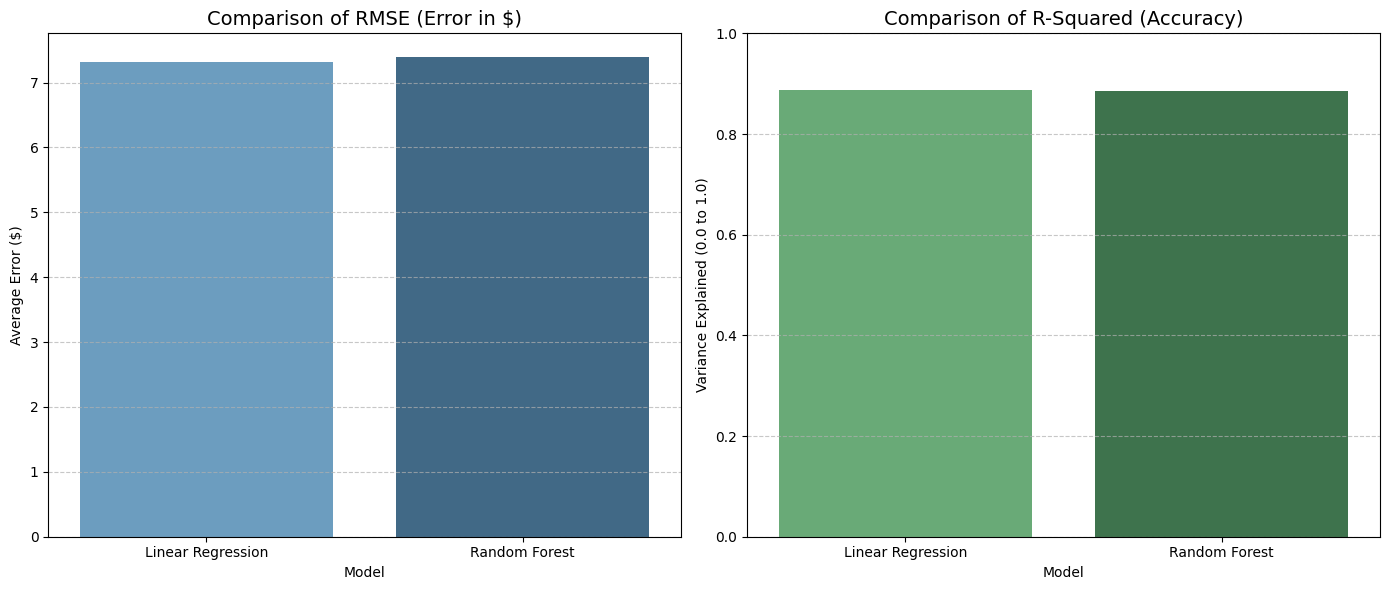

In [0]:
# 4.8 Model Performance & Feature Importance Visualization

# Visualize Model Comparison

# Verification Step: Print values to check for errors
print(f"DEBUG - Linear Regression: RMSE={lr_rmse:.4f}, R2={lr_r2:.4f}")
print(f"DEBUG - Random Forest:     RMSE={rf_rmse:.4f}, R2={rf_r2:.4f}")

#Ensure lr_rmse/rf_rmse are used for 'RMSE' and lr_r2/rf_r2 for 'R2'
metrics_plot_df = pd.DataFrame({
    'Metric': ['RMSE', 'RMSE', 'R2', 'R2'],
    'Model': ['Linear Regression', 'Random Forest', 'Linear Regression', 'Random Forest'],
    'Value': [float(lr_rmse), float(rf_rmse), float(lr_r2), float(rf_r2)]
})

# Create the plots
plt.figure(figsize=(14, 6))

# Plot 1: RMSE (Lower is better)
plt.subplot(1, 2, 1)
rmse_data = metrics_plot_df[metrics_plot_df['Metric'] == 'RMSE']
sns.barplot(x='Model', y='Value', data=rmse_data, palette='Blues_d')
plt.title('Comparison of RMSE (Error in $)', fontsize=14)
plt.ylabel('Average Error ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: R-Squared (Higher is better)
plt.subplot(1, 2, 2)
r2_data = metrics_plot_df[metrics_plot_df['Metric'] == 'R2']
sns.barplot(x='Model', y='Value', data=r2_data, palette='Greens_d')
plt.title('Comparison of R-Squared (Accuracy)', fontsize=14)
plt.ylabel('Variance Explained (0.0 to 1.0)')
plt.ylim(0, 1.0) # R2 is always between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#Section 5: Machine Learning Algorithm - Operational Efficiency Model
- Apply operational efficiency model to the dataset: random forest 
- Evaluate the model result with r2, mae, rmse

In [0]:
# 5. Operation Efficiency

from pyspark.sql.functions import col, round, avg

# Define the Operational Efficiency metric
# Using round() to keep the target clean for the ML model
df_efficiency = df_ml.withColumn(
    "rev_per_min", 
    round(col("total_amount") / col("trip_duration_min"), 2)
)

# Data Integrity: Remove trips where duration is 0 or efficiency is unrealistically high
df_efficiency = df_efficiency.filter((col("trip_duration_min") > 0) & (col("rev_per_min") < 5))

print(f"Efficiency dataset ready. Row count: {df_efficiency.count()}")
display(df_efficiency.select("trip_duration_min", "total_amount", "rev_per_min").limit(5))

Efficiency dataset ready. Row count: 2771268


trip_duration_min,total_amount,rev_per_min
36.6,85.09,2.32
11.733333333333333,16.4,1.4
12.85,17.8,1.39
4.616666666666666,15.48,3.35
23.85,29.7,1.25


In [0]:
# 5.1 Training the Operation Efficiency Model

# Initialize the Assembler 
# 'final_features' list created in Section 3.5
assembler = VectorAssembler(
    inputCols=final_features, 
    outputCol="final_features", # This creates the column the model is looking for
    handleInvalid="skip"
)

#Apply the assembly to the efficiency dataframe
df_efficiency_assembled = assembler.transform(df_efficiency)

#Split the ASSEMBLED data for the new target
train_eff_df, test_eff_df = df_efficiency_assembled.randomSplit([0.8, 0.2], seed=42)

# Define and Fit the RF for Efficiency
rf_efficiency = RandomForestRegressor(
    featuresCol="final_features", # Now this column exists!
    labelCol="rev_per_min",
    numTrees=30,
    maxDepth=7,
    seed=42
)

# Fit the model
eff_model = rf_efficiency.fit(train_eff_df)
eff_preds = eff_model.transform(test_eff_df)

print("Efficiency Model Training Complete.")

Efficiency Model Training Complete.


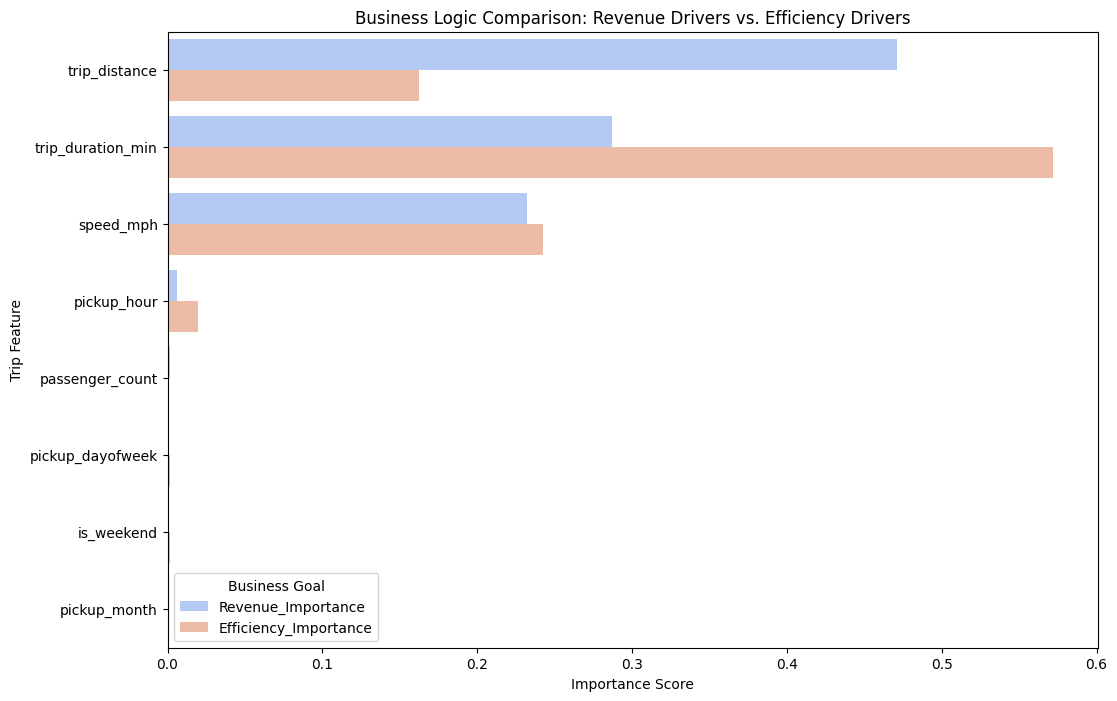

In [0]:
# 5.2 Compare "Revenue (Model 1)" vs "Efficiency (Model 2)"

# Get Importances from the Revenue Model (rf_model)
rev_importances = rf_model.featureImportances.toArray()
# Get Importances from the Efficiency Model (eff_model)
eff_importances = eff_model.featureImportances.toArray()

# Create a combined DataFrame for comparison
comparison_fi = pd.DataFrame({
    'Feature': final_features,
    'Revenue_Importance': rev_importances,
    'Efficiency_Importance': eff_importances
}).sort_values(by='Revenue_Importance', ascending=False)

# Visualization: Side-by-Side Bar Chart
# "melt" the dataframe to make it compatible with Seaborn
df_melted = comparison_fi.melt(id_vars='Feature', var_name='Objective', value_name='Importance')

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', hue='Objective', data=df_melted, palette='coolwarm')
plt.title('Business Logic Comparison: Revenue Drivers vs. Efficiency Drivers')
plt.xlabel('Importance Score')
plt.ylabel('Trip Feature')
plt.legend(title='Business Goal')
plt.show()

### 6. Hyperparameter Tuning (Manual, Databricks-Safe)
This section manually tests multiple parameter combinations for the revenue and efficiency models.
A sampled training subset is used to reduce runtime and avoid shared-cluster Spark ML tuning issues.

In [0]:
# ============================================================
# 6. — MANUAL HYPERPARAMETER TUNING (Databricks-safe version)
# Avoids CrossValidator temp-path issues on shared/serverless clusters
# Tunes:
#   Model 1 -> Revenue Prediction (total_amount)
#   Model 2 -> Efficiency Prediction (rev_per_min)
# ============================================================

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.functions import col, round
import pandas as pd

# ------------------------------------------------------------
# 6.1 Safety checks
# ------------------------------------------------------------
assert "df_ml" in globals(), "df_ml is missing. Run Section 3.5 first."
assert "final_features" in globals(), "final_features is missing. Run Section 3.5 first."

label_col = "total_amount"

print("Using features:")
print(final_features)

# Evaluators
rev_rmse_eval = RegressionEvaluator(
    labelCol="total_amount",
    predictionCol="prediction",
    metricName="rmse"
)

rev_mae_eval = RegressionEvaluator(
    labelCol="total_amount",
    predictionCol="prediction",
    metricName="mae"
)

rev_r2_eval = RegressionEvaluator(
    labelCol="total_amount",
    predictionCol="prediction",
    metricName="r2"
)

Using features:
['passenger_count', 'trip_distance', 'pickup_hour', 'pickup_dayofweek', 'pickup_month', 'is_weekend', 'trip_duration_min', 'speed_mph']


In [0]:
# ============================================================
# 6.2 Tune Linear Regression for Revenue
# ============================================================
print("\n=== Tuning Linear Regression: Revenue Model ===")

lr_results = []

lr_reg_params = [0.01, 0.1, 0.5]
lr_elastic_params = [0.0, 0.3, 0.5, 1.0]
lr_max_iters = [30, 50]

for reg in lr_reg_params:
    for elastic in lr_elastic_params:
        for max_iter in lr_max_iters:
            lr = LinearRegression(
                featuresCol="final_features",
                labelCol="total_amount",
                predictionCol="prediction",
                regParam=reg,
                elasticNetParam=elastic,
                maxIter=max_iter
            )

            model = lr.fit(train_df)
            preds = model.transform(test_df)

            rmse = rev_rmse_eval.evaluate(preds)
            mae = rev_mae_eval.evaluate(preds)
            r2 = rev_r2_eval.evaluate(preds)

            lr_results.append({
                "model": "Linear Regression",
                "regParam": reg,
                "elasticNetParam": elastic,
                "maxIter": max_iter,
                "RMSE": rmse,
                "MAE": mae,
                "R2": r2
            })

            print(
                f"LR | regParam={reg}, elasticNetParam={elastic}, maxIter={max_iter} "
                f"-> RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}"
            )

lr_results_df = pd.DataFrame(lr_results).sort_values("RMSE")
best_lr_params = lr_results_df.iloc[0]

print("\nBest Revenue Linear Regression:")
print(best_lr_params)

# Train best LR model again
best_lr_model = LinearRegression(
    featuresCol="final_features",
    labelCol="total_amount",
    predictionCol="prediction",
    regParam=float(best_lr_params["regParam"]),
    elasticNetParam=float(best_lr_params["elasticNetParam"]),
    maxIter=int(best_lr_params["maxIter"])
).fit(train_df)

best_lr_preds = best_lr_model.transform(test_df)

best_lr_rmse = rev_rmse_eval.evaluate(best_lr_preds)
best_lr_mae = rev_mae_eval.evaluate(best_lr_preds)
best_lr_r2 = rev_r2_eval.evaluate(best_lr_preds)




=== Tuning Linear Regression: Revenue Model ===
LR | regParam=0.01, elasticNetParam=0.0, maxIter=30 -> RMSE=7.3169, MAE=3.5344, R2=0.8868
LR | regParam=0.01, elasticNetParam=0.0, maxIter=50 -> RMSE=7.3169, MAE=3.5344, R2=0.8868
LR | regParam=0.01, elasticNetParam=0.3, maxIter=30 -> RMSE=7.3168, MAE=3.5344, R2=0.8868
LR | regParam=0.01, elasticNetParam=0.3, maxIter=50 -> RMSE=7.3168, MAE=3.5344, R2=0.8868
LR | regParam=0.01, elasticNetParam=0.5, maxIter=30 -> RMSE=7.3167, MAE=3.5344, R2=0.8868
LR | regParam=0.01, elasticNetParam=0.5, maxIter=50 -> RMSE=7.3167, MAE=3.5344, R2=0.8868
LR | regParam=0.01, elasticNetParam=1.0, maxIter=30 -> RMSE=7.3165, MAE=3.5344, R2=0.8868
LR | regParam=0.01, elasticNetParam=1.0, maxIter=50 -> RMSE=7.3165, MAE=3.5344, R2=0.8868
LR | regParam=0.1, elasticNetParam=0.0, maxIter=30 -> RMSE=7.3233, MAE=3.5382, R2=0.8866
LR | regParam=0.1, elasticNetParam=0.0, maxIter=50 -> RMSE=7.3233, MAE=3.5382, R2=0.8866
LR | regParam=0.1, elasticNetParam=0.3, maxIter=30 ->

In [0]:
# ===========================================
# 6.4 Tune Random Forest for Revenue Model
# ===========================================
print("\n=== Tuning Random Forest: Revenue Model ===")

import pandas as pd
from pyspark.ml.regression import RandomForestRegressor

rf_results = []

# Keep the grid very small
rf_num_trees = [10, 30, 50]
rf_max_depths = [5, 7, 10]

for num_trees in rf_num_trees:
    for max_depth in rf_max_depths:
        rf = RandomForestRegressor(
            featuresCol="final_features",
            labelCol="total_amount",
            predictionCol="prediction",
            numTrees=num_trees,
            maxDepth=max_depth,
            seed=42
        )

        model = rf.fit(train_df)
        preds = model.transform(test_df)

        rmse = rev_rmse_eval.evaluate(preds)
        mae = rev_mae_eval.evaluate(preds)
        r2 = rev_r2_eval.evaluate(preds)

        rf_results.append({
            "model": "Random Forest",
            "numTrees": num_trees,
            "maxDepth": max_depth,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2
        })

        print(
            f"RF | numTrees={num_trees}, maxDepth={max_depth} "
            f"-> RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}"
        )

rf_results_df = pd.DataFrame(rf_results).sort_values("RMSE")
best_rf_params = rf_results_df.iloc[0]

print("\nBest Revenue Random Forest:")
print(best_rf_params)


=== Tuning Random Forest: Revenue Model ===
RF | numTrees=10, maxDepth=5 -> RMSE=8.2210, MAE=3.7117, R2=0.8571
RF | numTrees=10, maxDepth=7 -> RMSE=7.6534, MAE=3.3192, R2=0.8761
RF | numTrees=10, maxDepth=10 -> RMSE=7.4038, MAE=3.0639, R2=0.8841
RF | numTrees=30, maxDepth=5 -> RMSE=7.9934, MAE=3.4762, R2=0.8649
RF | numTrees=30, maxDepth=7 -> RMSE=7.5567, MAE=3.1817, R2=0.8793
RF | numTrees=30, maxDepth=10 -> RMSE=7.3847, MAE=3.0266, R2=0.8847
RF | numTrees=50, maxDepth=5 -> RMSE=8.0033, MAE=3.5059, R2=0.8646
RF | numTrees=50, maxDepth=7 -> RMSE=7.5963, MAE=3.1850, R2=0.8780
RF | numTrees=50, maxDepth=10 -> RMSE=7.3890, MAE=3.0232, R2=0.8846

Best Revenue Random Forest:
model       Random Forest
numTrees               30
maxDepth               10
RMSE             7.384673
MAE              3.026621
R2               0.884688
Name: 5, dtype: object


In [0]:
# ===========================================
# 6.5 Final Random Forest for Revenue Model
# ===========================================

from pyspark.ml.regression import RandomForestRegressor

best_rf_model = RandomForestRegressor(
    featuresCol="final_features",
    labelCol="total_amount",
    predictionCol="prediction",
    numTrees=int(best_rf_params["numTrees"]),
    maxDepth=int(best_rf_params["maxDepth"]),
    seed=42
).fit(train_df)   # use train_rev_df instead if runtime allows

best_rf_preds = best_rf_model.transform(test_df)

best_rf_rmse = rev_rmse_eval.evaluate(best_rf_preds)
best_rf_mae = rev_mae_eval.evaluate(best_rf_preds)
best_rf_r2 = rev_r2_eval.evaluate(best_rf_preds)

print("\n=== Final Best Revenue RF Performance ===")
print(f"RMSE: {best_rf_rmse:.4f}")
print(f"MAE : {best_rf_mae:.4f}")
print(f"R2  : {best_rf_r2:.4f}")


=== Final Best Revenue RF Performance ===
RMSE: 7.3847
MAE : 3.0266
R2  : 0.8847


In [0]:
# ============================================================
# 6.5 Revenue model comparison
# ============================================================
print("\n=== FINAL REVENUE MODEL COMPARISON ===")
print(f"Best Linear Regression -> RMSE: {best_lr_rmse:.4f}, MAE: {best_lr_mae:.4f}, R2: {best_lr_r2:.4f}")
print(f"Best Random Forest     -> RMSE: {best_rf_rmse:.4f}, MAE: {best_rf_mae:.4f}, R2: {best_rf_r2:.4f}")

if best_rf_rmse < best_lr_rmse:
    print("Revenue Model Winner: Random Forest")
else:
    print("Revenue Model Winner: Linear Regression")

# Show revenue tuning tables
print("\nTop 5 Revenue Linear Regression settings:")
display(spark.createDataFrame(lr_results_df.head(5)))

print("\nTop 5 Revenue Random Forest settings:")
display(spark.createDataFrame(rf_results_df.head(5)))

# Note:
# rev_per_min is a derived business metric based on total_amount and trip_duration_min.
# It is used here to study operational efficiency rather than as a fully independent raw target.

# ============================================================
# 6.6 — EFFICIENCY MODEL TUNING
# Target: rev_per_min = total_amount / trip_duration_min
# ============================================================
print("\n=== Preparing Efficiency Dataset ===")

assert "df_features" in globals(), "df_features is missing. Run Section 3.1 first."

df_efficiency = df_features.withColumn(
    "rev_per_min",
    round(col("total_amount") / col("trip_duration_min"), 2)
).filter(
    (col("trip_duration_min") > 0) &
    (col("rev_per_min") < 5)
)

df_eff_ready = assembler.transform(df_efficiency).select("final_features", "rev_per_min")

train_eff_df, test_eff_df = df_eff_ready.randomSplit([0.8, 0.2], seed=42)

eff_rmse_eval = RegressionEvaluator(
    labelCol="rev_per_min",
    predictionCol="prediction",
    metricName="rmse"
)

eff_mae_eval = RegressionEvaluator(
    labelCol="rev_per_min",
    predictionCol="prediction",
    metricName="mae"
)

eff_r2_eval = RegressionEvaluator(
    labelCol="rev_per_min",
    predictionCol="prediction",
    metricName="r2"
)



=== FINAL REVENUE MODEL COMPARISON ===
Best Linear Regression -> RMSE: 7.3165, MAE: 3.5344, R2: 0.8868
Best Random Forest     -> RMSE: 7.3847, MAE: 3.0266, R2: 0.8847
Revenue Model Winner: Linear Regression

Top 5 Revenue Linear Regression settings:


model,regParam,elasticNetParam,maxIter,RMSE,MAE,R2
Linear Regression,0.01,1.0,50,7.316547284228129,3.5343801871745866,0.8868055260898912
Linear Regression,0.01,1.0,30,7.316547303939961,3.534380331888633,0.8868055254799667
Linear Regression,0.01,0.5,30,7.316702680236056,3.534381070117515,0.8868007177682941
Linear Regression,0.01,0.5,50,7.316702680236056,3.534381070117515,0.8868007177682941
Linear Regression,0.01,0.3,30,7.316777485996679,3.5344008777771356,0.8867984030639614



Top 5 Revenue Random Forest settings:


model,numTrees,maxDepth,RMSE,MAE,R2
Random Forest,30,10,7.384672634179673,3.0266212111411837,0.8846877746844416
Random Forest,50,10,7.389004433894179,3.023241880522494,0.8845524522418872
Random Forest,10,10,7.403783968946843,3.063894013009604,0.884090152474332
Random Forest,30,7,7.556659558778464,3.181683779940191,0.8792540502435484
Random Forest,50,7,7.5963004146028545,3.1850247319235487,0.8779839050876528



=== Preparing Efficiency Dataset ===


In [0]:
# ============================================================
# 6.7 Tune Random Forest for Efficiency
# ============================================================
print("\n=== Tuning Random Forest: Efficiency Model ===")

eff_results = []

eff_num_trees = [10, 30, 50]
eff_max_depths = [5, 7, 10]

for num_trees in eff_num_trees:
    for max_depth in eff_max_depths:
        rf_eff = RandomForestRegressor(
            featuresCol="final_features",
            labelCol="rev_per_min",
            predictionCol="prediction",
            numTrees=num_trees,
            maxDepth=max_depth,
            seed=42
        )

        model = rf_eff.fit(train_eff_df)
        preds = model.transform(test_eff_df)

        rmse = eff_rmse_eval.evaluate(preds)
        mae = eff_mae_eval.evaluate(preds)
        r2 = eff_r2_eval.evaluate(preds)

        eff_results.append({
            "model": "RF Efficiency",
            "numTrees": num_trees,
            "maxDepth": max_depth,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2
        })

        print(
            f"EFF RF | numTrees={num_trees}, maxDepth={max_depth} "
            f"-> RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}"
        )

eff_results_df = pd.DataFrame(eff_results).sort_values("RMSE")
best_eff_params = eff_results_df.iloc[0]

print("\nBest Efficiency Random Forest:")
print(best_eff_params)

# Train best efficiency model again
best_eff_model = RandomForestRegressor(
    featuresCol="final_features",
    labelCol="rev_per_min",
    predictionCol="prediction",
    numTrees=int(best_eff_params["numTrees"]),
    maxDepth=int(best_eff_params["maxDepth"]),
    seed=42
).fit(train_eff_df)

best_eff_preds = best_eff_model.transform(test_eff_df)

best_eff_rmse = eff_rmse_eval.evaluate(best_eff_preds)
best_eff_mae = eff_mae_eval.evaluate(best_eff_preds)
best_eff_r2 = eff_r2_eval.evaluate(best_eff_preds)

print("\n=== FINAL EFFICIENCY MODEL RESULT ===")
print(f"Best Efficiency RF -> RMSE: {best_eff_rmse:.4f}, MAE: {best_eff_mae:.4f}, R2: {best_eff_r2:.4f}")

print("\nTop 5 Efficiency Random Forest settings:")
display(spark.createDataFrame(eff_results_df.head(5)))

# ============================================================
# 6.8 — FINAL SUMMARY TABLE
# ============================================================
summary_df = pd.DataFrame([
    {
        "Model": "Revenue - Linear Regression",
        "RMSE": best_lr_rmse,
        "MAE": best_lr_mae,
        "R2": best_lr_r2
    },
    {
        "Model": "Revenue - Random Forest",
        "RMSE": best_rf_rmse,
        "MAE": best_rf_mae,
        "R2": best_rf_r2
    },
    {
        "Model": "Efficiency - Random Forest",
        "RMSE": best_eff_rmse,
        "MAE": best_eff_mae,
        "R2": best_eff_r2
    }
]).sort_values("RMSE")

print("\n=== FINAL MODEL SUMMARY ===")
display(spark.createDataFrame(summary_df))


=== Tuning Random Forest: Efficiency Model ===
EFF RF | numTrees=10, maxDepth=5 -> RMSE=0.3201, MAE=0.2280, R2=0.7936
EFF RF | numTrees=10, maxDepth=7 -> RMSE=0.2846, MAE=0.1993, R2=0.8367
EFF RF | numTrees=10, maxDepth=10 -> RMSE=0.2653, MAE=0.1840, R2=0.8582
EFF RF | numTrees=30, maxDepth=5 -> RMSE=0.3195, MAE=0.2286, R2=0.7942
EFF RF | numTrees=30, maxDepth=7 -> RMSE=0.2850, MAE=0.1992, R2=0.8362
EFF RF | numTrees=30, maxDepth=10 -> RMSE=0.2643, MAE=0.1833, R2=0.8592
EFF RF | numTrees=50, maxDepth=5 -> RMSE=0.3207, MAE=0.2316, R2=0.7928
EFF RF | numTrees=50, maxDepth=7 -> RMSE=0.2836, MAE=0.1987, R2=0.8379
EFF RF | numTrees=50, maxDepth=10 -> RMSE=0.2638, MAE=0.1829, R2=0.8597

Best Efficiency Random Forest:
model       RF Efficiency
numTrees               50
maxDepth               10
RMSE              0.26384
MAE               0.18294
R2               0.859705
Name: 8, dtype: object

=== FINAL EFFICIENCY MODEL RESULT ===
Best Efficiency RF -> RMSE: 0.2638, MAE: 0.1829, R2: 0.8597


model,numTrees,maxDepth,RMSE,MAE,R2
RF Efficiency,50,10,0.26383963363678303,0.1829401171725796,0.8597053180270621
RF Efficiency,30,10,0.26427042638354414,0.18326146360222645,0.8592468025904776
RF Efficiency,10,10,0.26528999676196824,0.18401661336530742,0.858158639807105
RF Efficiency,50,7,0.28356039507140046,0.19868899130980708,0.8379487878383952
RF Efficiency,10,7,0.2846392146272969,0.19928999069671982,0.8367133784999068



=== FINAL MODEL SUMMARY ===


Model,RMSE,MAE,R2
Efficiency - Random Forest,0.26383963363678303,0.1829401171725796,0.8597053180270621
Revenue - Linear Regression,7.316547284228129,3.5343801871745866,0.8868055260898912
Revenue - Random Forest,7.384672634179673,3.0266212111411837,0.8846877746844416
